# Exploratory Data Analysis

Jonas J.R. Koberschinski  
2025-02-11

In [ ]:
#| label: setup
#| include: false
# Global setup: libraries & options

library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Attaching package: 'psych'

The following objects are masked from 'package:ggplot2':

    %+%, alpha

...

The following object is masked from 'package:dplyr':

    recode


Attaching package: 'DescTools'

The following objects are masked from 'package:psych':

    AUC, ICC, SD


Attaching package: 'crosstable'

The following object is masked from 'package:DescTools':

    N

## Data import

In [ ]:
#| label: data-import
#| echo: true

# load mean&median data
# List of file names (without paths and extension)
file_names <- c(
  "bdnf_mean.txt",
  "bdnf_median.txt",
  
  "tau_mean.txt",
  "tau_median.txt",
  
  "psd95_mean.txt",
  "psd95_median.txt"
)

# Folder where the files are located
subfolder <- "/home/kobi/Work/TBM-R-Analysis/tables/mean&median_tables"

# Loop through the file names, read each table, and assign it to a variable
for (file_name in file_names) {
  # Construct the full file path by combining the subfolder and file name
  file_path <- file.path(subfolder, file_name)
  
  # Remove the .txt extension to get the base name for the variable
  var_name <- tools::file_path_sans_ext(file_name)
  
  # Read the table and assign it to a variable with the same name
  assign(var_name, read.table(file_path, sep = "\t", header = TRUE, row.names = NULL, quote = ""))
}


# load cpg-data
cpg <- read.table(file = '/home/kobi/Work/TBM-R-Analysis/tables/Ausgangstabellen/cpg.txt', sep = "\t", header = TRUE, row.names = NULL, quote = "")


# load wide data
# List of file names (without paths and extension)
file_names_wide <- c(
  "bdnf_mean_wide.txt",
  "bdnf_median_wide.txt",
  
  "tau_mean_wide.txt",
  "tau_median_wide.txt",
  
  "psd95_mean_wide.txt",
  "psd95_median_wide.txt"
)

# Folder where the files are located
subfolder_wide <- "/home/kobi/Work/TBM-R-Analysis/tables/wide_format/"

# Loop through the file names, read each table, and assign it to a variable
for (file_name in file_names_wide) {
  # Construct the full file path by combining the subfolder and file name
  file_path <- file.path(subfolder_wide, file_name)
  
  # Remove the .txt extension to get the base name for the variable
  var_name <- tools::file_path_sans_ext(file_name)
  
  # Read the table and assign it to a variable with the same name
  assign(var_name, read.table(file_path, sep = "\t", header = TRUE, row.names = NULL, quote = ""))
}

# EDA (Exploratory Data Analysis)

## Basic demopgrahics (Code to table summarized by chatgpt beyogen auf bdnf)

``` r
#| label: tbl-demographics
#| results: asis

mean_sd <- function(x, digits_mean = 2, digits_sd = 1) {
  m <- mean(x, na.rm = TRUE)
  s <- sd(x, na.rm = TRUE)
  sprintf(paste0("%.", digits_mean, "f \u00B1 %.", digits_sd, "f"), m, s)
}

min_max <- function(x, digits = 0) {
  mn <- min(x, na.rm = TRUE)
  mx <- max(x, na.rm = TRUE)
  sprintf(paste0("%.", digits, "f / %.", digits, "f"), mn, mx)
}

female_male_pct <- function(sex_vec, digits = 1) {
  tab <- prop.table(table(sex_vec)) * 100
  f <- unname(tab["F"]); m <- unname(tab["M"])
  if (is.na(f)) f <- 0
  if (is.na(m)) m <- 0
  sprintf(paste0("%.", digits, "f / %.", digits, "f"), f, m)
}

group_stats <- function(df) {
  list(
    mean_age_sd = mean_sd(df$Age_start, 2, 1),
    min_max     = min_max(df$Age_start, 0),
    n           = nrow(df),
    fm_pct      = female_male_pct(df$Sex, 1)
  )
}

bdnf_piano   <- subset(bdnf_median_wide, Gruppe == "Piano")
bdnf_control <- subset(bdnf_median_wide, Gruppe == "Controll")

p <- group_stats(bdnf_piano)
c <- group_stats(bdnf_control)

cat(paste0(
  "| Characteristic        | Piano Group | Control Group |\n",
  "|-----------------------|------------:|--------------:|\n",
  "| Mean age \u00B1 SD (years) | ", p$mean_age_sd, " | ", c$mean_age_sd, " |\n",
  "| Min / Max             | ", p$min_max, " | ", c$min_max, " |\n",
  "| N                     | ", p$n, " | ", c$n, " |\n",
  "| Female / Male (%)     | ", p$fm_pct, " | ", c$fm_pct, " |\n"
))
```

| Characteristic        | Piano Group | Control Group |
|-----------------------|------------:|--------------:|
| Mean age ± SD (years) | 69.45 ± 3.2 |   69.70 ± 3.8 |
| Min / Max             |     64 / 77 |       62 / 78 |
| N                     |          67 |            77 |
| Female / Male (%)     | 55.2 / 44.8 |   59.7 / 40.3 |

### Extended (bezogen auf bdnf!)

``` r
#| label: table1-demographics
#| results: asis

# ---- (5) robust labels: standardize Gruppe and Sex ----
df <- bdnf_median_wide
df$Gruppe <- trimws(df$Gruppe)
df$Sex    <- trimws(df$Sex)

df$Sex <- toupper(df$Sex)
df$Sex[df$Sex %in% c("FEMALE")] <- "F"
df$Sex[df$Sex %in% c("MALE")]   <- "M"

g_piano   <- "Piano"
g_control <- "Controll"

df_piano   <- subset(df, Gruppe == g_piano)
df_control <- subset(df, Gruppe == g_control)
df_overall <- df

# ---- helpers ----
fmt_mean_sd <- function(x, dm = 2, ds = 1) {
  m <- mean(x, na.rm = TRUE); s <- sd(x, na.rm = TRUE)
  sprintf(paste0("%.", dm, "f \u00B1 %.", ds, "f"), m, s)
}
fmt_median_iqr <- function(x, d = 2) {
  med <- median(x, na.rm = TRUE)
  q <- quantile(x, probs = c(0.25, 0.75), na.rm = TRUE, names = FALSE)
  sprintf(paste0("%.", d, "f (%.", d, "f, %.", d, "f)"), med, q[1], q[2])
}
fmt_min_max <- function(x, d = 0) {
  mn <- min(x, na.rm = TRUE); mx <- max(x, na.rm = TRUE)
  sprintf(paste0("%.", d, "f / %.", d, "f"), mn, mx)
}
n_nonmiss <- function(x) sum(!is.na(x))

fmt_fm_pct <- function(sex_vec, d = 1) {
  tab <- prop.table(table(sex_vec)) * 100
  f <- unname(tab["F"]); m <- unname(tab["M"])
  if (is.na(f)) f <- 0
  if (is.na(m)) m <- 0
  sprintf(paste0("%.", d, "f / %.", d, "f"), f, m)
}
fmt_missing <- function(x) {
  n_miss <- sum(is.na(x))
  n_tot  <- length(x)
  sprintf("%d (%0.1f%%)", n_miss, 100 * n_miss / n_tot)
}

summ_one <- function(d) {
  list(
    n_participants = nrow(d),
    age_nonmiss    = n_nonmiss(d$Age_start),
    age_mean_sd    = fmt_mean_sd(d$Age_start, 2, 1),
    age_median_iqr = fmt_median_iqr(d$Age_start, 2),
    age_min_max    = fmt_min_max(d$Age_start, 0),
    sex_fm_pct     = fmt_fm_pct(d$Sex, 1),
    sex_missing    = fmt_missing(d$Sex),

    t0_n           = n_nonmiss(d$T0),
    t1_n           = n_nonmiss(d$T1),
    t2_n           = n_nonmiss(d$T2),
    t0_missing     = fmt_missing(d$T0),
    t1_missing     = fmt_missing(d$T1),
    t2_missing     = fmt_missing(d$T2),
    total_samples  = n_nonmiss(d$T0) + n_nonmiss(d$T1) + n_nonmiss(d$T2)
  )
}

P <- summ_one(df_piano)
C <- summ_one(df_control)
O <- summ_one(df_overall)

cat(paste0(
  "| Characteristic | Piano | Control | Overall |\n",
  "|---|---:|---:|---:|\n",
  "| Participants (N) | ", P$n_participants, " | ", C$n_participants, " | ", O$n_participants, " |\n",
  "| Age non-missing (n) | ", P$age_nonmiss, " | ", C$age_nonmiss, " | ", O$age_nonmiss, " |\n",
  "| Mean age \u00B1 SD (years) | ", P$age_mean_sd, " | ", C$age_mean_sd, " | ", O$age_mean_sd, " |\n",
  "| Median (IQR) age (years) | ", P$age_median_iqr, " | ", C$age_median_iqr, " | ", O$age_median_iqr, " |\n",
  "| Min / Max age (years) | ", P$age_min_max, " | ", C$age_min_max, " | ", O$age_min_max, " |\n",
  "| Female / Male (%) | ", P$sex_fm_pct, " | ", C$sex_fm_pct, " | ", O$sex_fm_pct, " |\n",
  "| Sex missing, n (%) | ", P$sex_missing, " | ", C$sex_missing, " | ", O$sex_missing, " |\n",
  "| BDNF samples at T0 (n) | ", P$t0_n, " | ", C$t0_n, " | ", O$t0_n, " |\n",
  "| BDNF samples at T1 (n) | ", P$t1_n, " | ", C$t1_n, " | ", O$t1_n, " |\n",
  "| BDNF samples at T2 (n) | ", P$t2_n, " | ", C$t2_n, " | ", O$t2_n, " |\n",
  "| Total BDNF samples (T0+T1+T2) | ", P$total_samples, " | ", C$total_samples, " | ", O$total_samples, " |\n",
  "| Missing T0, n (%) | ", P$t0_missing, " | ", C$t0_missing, " | ", O$t0_missing, " |\n",
  "| Missing T1, n (%) | ", P$t1_missing, " | ", C$t1_missing, " | ", O$t1_missing, " |\n",
  "| Missing T2, n (%) | ", P$t2_missing, " | ", C$t2_missing, " | ", O$t2_missing, " |\n"
))
```

| Characteristic | Piano | Control | Overall |
|---------------|------------------:|------------------:|------------------:|
| Participants (N) | 67 | 77 | 144 |
| Age non-missing (n) | 67 | 77 | 144 |
| Mean age ± SD (years) | 69.45 ± 3.2 | 69.70 ± 3.8 | 69.58 ± 3.5 |
| Median (IQR) age (years) | 69.00 (67.00, 71.00) | 69.00 (67.00, 73.00) | 69.00 (67.00, 71.25) |
| Min / Max age (years) | 64 / 77 | 62 / 78 | 62 / 78 |
| Female / Male (%) | 55.2 / 44.8 | 59.7 / 40.3 | 57.6 / 42.4 |
| Sex missing, n (%) | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) |
| BDNF samples at T0 (n) | 65 | 75 | 140 |
| BDNF samples at T1 (n) | 61 | 61 | 122 |
| BDNF samples at T2 (n) | 50 | 47 | 97 |
| Total BDNF samples (T0+T1+T2) | 176 | 183 | 359 |
| Missing T0, n (%) | 2 (3.0%) | 2 (2.6%) | 4 (2.8%) |
| Missing T1, n (%) | 6 (9.0%) | 16 (20.8%) | 22 (15.3%) |
| Missing T2, n (%) | 17 (25.4%) | 30 (39.0%) | 47 (32.6%) |

### Table with all genes

``` r
#| label: table-samples-bdnf-tau-psd95
#| results: asis

# helper: robust trimming
prep_df <- function(df) {
  df$Gruppe <- trimws(df$Gruppe)
  df
}

n_nonmiss <- function(x) sum(!is.na(x))

# summarize one biomarker wide-df into a named row
summ_marker <- function(df, marker, g_piano = "Piano", g_control = "Controll") {
  df <- prep_df(df)

  dP <- subset(df, Gruppe == g_piano)
  dC <- subset(df, Gruppe == g_control)
  dO <- df

  c(
    Marker = marker,

    Piano_T0 = n_nonmiss(dP$T0),
    Piano_T1 = n_nonmiss(dP$T1),
    Piano_T2 = n_nonmiss(dP$T2),
    Piano_Total = n_nonmiss(dP$T0) + n_nonmiss(dP$T1) + n_nonmiss(dP$T2),

    Control_T0 = n_nonmiss(dC$T0),
    Control_T1 = n_nonmiss(dC$T1),
    Control_T2 = n_nonmiss(dC$T2),
    Control_Total = n_nonmiss(dC$T0) + n_nonmiss(dC$T1) + n_nonmiss(dC$T2),

    Overall_T0 = n_nonmiss(dO$T0),
    Overall_T1 = n_nonmiss(dO$T1),
    Overall_T2 = n_nonmiss(dO$T2),
    Overall_Total = n_nonmiss(dO$T0) + n_nonmiss(dO$T1) + n_nonmiss(dO$T2)
  )
}

rows <- rbind(
  summ_marker(bdnf_median_wide,  "BDNF"),
  summ_marker(tau_median_wide,   "TAU"),
  summ_marker(psd95_median_wide, "PSD95")
)

# render as markdown table
cat(paste0(
  "| Marker | Piano T0 | Piano T1 | Piano T2 | Piano Total | Control T0 | Control T1 | Control T2 | Control Total | Overall T0 | Overall T1 | Overall T2 | Overall Total |\n",
  "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|\n",
  paste(apply(rows, 1, function(r) {
    paste0("| ", r["Marker"], " | ",
           r["Piano_T0"], " | ", r["Piano_T1"], " | ", r["Piano_T2"], " | ", r["Piano_Total"], " | ",
           r["Control_T0"], " | ", r["Control_T1"], " | ", r["Control_T2"], " | ", r["Control_Total"], " | ",
           r["Overall_T0"], " | ", r["Overall_T1"], " | ", r["Overall_T2"], " | ", r["Overall_Total"], " |")
  }), collapse = "\n"),
  "\n"
))
```

| Marker | Piano T0 | Piano T1 | Piano T2 | Piano Total | Control T0 | Control T1 | Control T2 | Control Total | Overall T0 | Overall T1 | Overall T2 | Overall Total |
|-----|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| BDNF | 65 | 61 | 50 | 176 | 75 | 61 | 47 | 183 | 140 | 122 | 97 | 359 |
| TAU | 67 | 63 | 50 | 180 | 75 | 60 | 47 | 182 | 142 | 123 | 97 | 362 |
| PSD95 | 66 | 63 | 49 | 178 | 73 | 59 | 47 | 179 | 139 | 122 | 96 | 357 |

### another demopgrahic (bezogen auf BDNF! villeicht ändern)

In [ ]:
summ_one <- function(d) {
  list(
    n_participants = nrow(d),
    age_nonmiss    = n_nonmiss(d$Age_start),
    age_mean_sd    = fmt_mean_sd(d$Age_start, 2, 1),
    age_median_iqr = fmt_median_iqr(d$Age_start, 2),
    age_min_max    = fmt_min_max(d$Age_start, 0),
    sex_fm_pct     = fmt_fm_pct(d$Sex, 1),
    sex_missing    = fmt_missing(d$Sex)
  )
}

P <- summ_one(df_piano)
C <- summ_one(df_control)
O <- summ_one(df_overall)

cat(paste0(
  "| Characteristic | Piano | Control | Overall |\n",
  "|---|---:|---:|---:|\n",
  "| Participants (N) | ", P$n_participants, " | ", C$n_participants, " | ", O$n_participants, " |\n",
  "| Age non-missing (n) | ", P$age_nonmiss, " | ", C$age_nonmiss, " | ", O$age_nonmiss, " |\n",
  "| Mean age \u00B1 SD (years) | ", P$age_mean_sd, " | ", C$age_mean_sd, " | ", O$age_mean_sd, " |\n",
  "| Median (IQR) age (years) | ", P$age_median_iqr, " | ", C$age_median_iqr, " | ", O$age_median_iqr, " |\n",
  "| Min / Max age (years) | ", P$age_min_max, " | ", C$age_min_max, " | ", O$age_min_max, " |\n",
  "| Female / Male (%) | ", P$sex_fm_pct, " | ", C$sex_fm_pct, " | ", O$sex_fm_pct, " |\n",
  "| Sex missing, n (%) | ", P$sex_missing, " | ", C$sex_missing, " | ", O$sex_missing, " |\n"
))

| Characteristic | Piano | Control | Overall |
|---|---:|---:|---:|
| Participants (N) | 67 | 77 | 144 |
| Age non-missing (n) | 67 | 77 | 144 |
| Mean age ± SD (years) | 69.45 ± 3.2 | 69.70 ± 3.8 | 69.58 ± 3.5 |
| Median (IQR) age (years) | 69.00 (67.00, 71.00) | 69.00 (67.00, 73.00) | 69.00 (67.00, 71.25) |
| Min / Max age (years) | 64 / 77 | 62 / 78 | 62 / 78 |
| Female / Male (%) | 55.2 / 44.8 | 59.7 / 40.3 | 57.6 / 42.4 |
| Sex missing, n (%) | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) |

### all genes with missing

``` r
#| label: table-genes-missing
#| results: asis

prep_df <- function(df) {
  df$Gruppe <- trimws(df$Gruppe)
  df
}

n_nonmiss <- function(x) sum(!is.na(x))

fmt_missing <- function(x) {
  n_miss <- sum(is.na(x))
  n_tot  <- length(x)
  sprintf("%d (%0.1f%%)", n_miss, 100 * n_miss / n_tot)
}

summ_marker <- function(df, marker, g_piano = "Piano", g_control = "Controll") {
  df <- prep_df(df)

  dP <- subset(df, Gruppe == g_piano)
  dC <- subset(df, Gruppe == g_control)
  dO <- df

  # counts
  P_t0 <- n_nonmiss(dP$T0); P_t1 <- n_nonmiss(dP$T1); P_t2 <- n_nonmiss(dP$T2)
  C_t0 <- n_nonmiss(dC$T0); C_t1 <- n_nonmiss(dC$T1); C_t2 <- n_nonmiss(dC$T2)
  O_t0 <- n_nonmiss(dO$T0); O_t1 <- n_nonmiss(dO$T1); O_t2 <- n_nonmiss(dO$T2)

  # missing (%)
  P_m0 <- fmt_missing(dP$T0); P_m1 <- fmt_missing(dP$T1); P_m2 <- fmt_missing(dP$T2)
  C_m0 <- fmt_missing(dC$T0); C_m1 <- fmt_missing(dC$T1); C_m2 <- fmt_missing(dC$T2)
  O_m0 <- fmt_missing(dO$T0); O_m1 <- fmt_missing(dO$T1); O_m2 <- fmt_missing(dO$T2)

  list(
    marker = marker,
    Piano   = list(t0 = P_t0, t1 = P_t1, t2 = P_t2,
                   tot = P_t0 + P_t1 + P_t2,
                   m0 = P_m0, m1 = P_m1, m2 = P_m2),
    Control = list(t0 = C_t0, t1 = C_t1, t2 = C_t2,
                   tot = C_t0 + C_t1 + C_t2,
                   m0 = C_m0, m1 = C_m1, m2 = C_m2),
    Overall = list(t0 = O_t0, t1 = O_t1, t2 = O_t2,
                   tot = O_t0 + O_t1 + O_t2,
                   m0 = O_m0, m1 = O_m1, m2 = O_m2)
  )
}

rows <- list(
  summ_marker(bdnf_median_wide,  "BDNF"),
  summ_marker(tau_median_wide,   "TAU"),
  summ_marker(psd95_median_wide, "PSD95")
)

cat(paste0(
  "| Marker | Piano T0 n | Piano T1 n | Piano T2 n | Piano Total | Piano missing T0 | Piano missing T1 | Piano missing T2 | Control T0 n | Control T1 n | Control T2 n | Control Total | Control missing T0 | Control missing T1 | Control missing T2 | Overall T0 n | Overall T1 n | Overall T2 n | Overall Total | Overall missing T0 | Overall missing T1 | Overall missing T2 |\n",
  "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|\n",
  paste(vapply(rows, function(r) {
    paste0(
      "| ", r$marker,
      " | ", r$Piano$t0, " | ", r$Piano$t1, " | ", r$Piano$t2, " | ", r$Piano$tot,
      " | ", r$Piano$m0, " | ", r$Piano$m1, " | ", r$Piano$m2,
      " | ", r$Control$t0, " | ", r$Control$t1, " | ", r$Control$t2, " | ", r$Control$tot,
      " | ", r$Control$m0, " | ", r$Control$m1, " | ", r$Control$m2,
      " | ", r$Overall$t0, " | ", r$Overall$t1, " | ", r$Overall$t2, " | ", r$Overall$tot,
      " | ", r$Overall$m0, " | ", r$Overall$m1, " | ", r$Overall$m2,
      " |"
    )
  }, character(1)), collapse = "\n"),
  "\n"
))
```

| Marker | Piano T0 n | Piano T1 n | Piano T2 n | Piano Total | Piano missing T0 | Piano missing T1 | Piano missing T2 | Control T0 n | Control T1 n | Control T2 n | Control Total | Control missing T0 | Control missing T1 | Control missing T2 | Overall T0 n | Overall T1 n | Overall T2 n | Overall Total | Overall missing T0 | Overall missing T1 | Overall missing T2 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| BDNF | 65 | 61 | 50 | 176 | 2 (3.0%) | 6 (9.0%) | 17 (25.4%) | 75 | 61 | 47 | 183 | 2 (2.6%) | 16 (20.8%) | 30 (39.0%) | 140 | 122 | 97 | 359 | 4 (2.8%) | 22 (15.3%) | 47 (32.6%) |
| TAU | 67 | 63 | 50 | 180 | 1 (1.5%) | 5 (7.4%) | 18 (26.5%) | 75 | 60 | 47 | 182 | 2 (2.6%) | 17 (22.1%) | 30 (39.0%) | 142 | 123 | 97 | 362 | 3 (2.1%) | 22 (15.2%) | 48 (33.1%) |
| PSD95 | 66 | 63 | 49 | 178 | 2 (2.9%) | 5 (7.4%) | 19 (27.9%) | 73 | 59 | 47 | 179 | 4 (5.2%) | 18 (23.4%) | 30 (39.0%) | 139 | 122 | 96 | 357 | 6 (4.1%) | 23 (15.9%) | 49 (33.8%) |

``` r
#| label: tables-per-marker
#| results: asis

# ---------- helpers ----------
fmt_mean_sd <- function(x, dm = 2, ds = 1) {
  m <- mean(x, na.rm = TRUE); s <- sd(x, na.rm = TRUE)
  sprintf(paste0("%.", dm, "f \u00B1 %.", ds, "f"), m, s)
}
fmt_median_iqr <- function(x, d = 2) {
  med <- median(x, na.rm = TRUE)
  q <- quantile(x, probs = c(0.25, 0.75), na.rm = TRUE, names = FALSE)
  sprintf(paste0("%.", d, "f (%.", d, "f, %.", d, "f)"), med, q[1], q[2])
}
fmt_min_max <- function(x, d = 0) {
  mn <- min(x, na.rm = TRUE); mx <- max(x, na.rm = TRUE)
  sprintf(paste0("%.", d, "f / %.", d, "f"), mn, mx)
}
n_nonmiss <- function(x) sum(!is.na(x))
fmt_missing <- function(x) {
  n_miss <- sum(is.na(x)); n_tot <- length(x)
  sprintf("%d (%0.1f%%)", n_miss, 100 * n_miss / n_tot)
}
fmt_fm_pct <- function(sex_vec, d = 1) {
  sex_vec <- trimws(toupper(sex_vec))
  sex_vec[sex_vec %in% c("FEMALE")] <- "F"
  sex_vec[sex_vec %in% c("MALE")]   <- "M"
  tab <- prop.table(table(sex_vec)) * 100
  f <- unname(tab["F"]); m <- unname(tab["M"])
  if (is.na(f)) f <- 0
  if (is.na(m)) m <- 0
  sprintf(paste0("%.", d, "f / %.", d, "f"), f, m)
}

summ_one <- function(d) {
  list(
    n_participants = nrow(d),
    age_nonmiss    = n_nonmiss(d$Age_start),
    age_mean_sd    = fmt_mean_sd(d$Age_start, 2, 1),
    age_median_iqr = fmt_median_iqr(d$Age_start, 2),
    age_min_max    = fmt_min_max(d$Age_start, 0),
    sex_fm_pct     = fmt_fm_pct(d$Sex, 1),
    sex_missing    = fmt_missing(d$Sex),

    t0_n           = n_nonmiss(d$T0),
    t1_n           = n_nonmiss(d$T1),
    t2_n           = n_nonmiss(d$T2),
    t0_missing     = fmt_missing(d$T0),
    t1_missing     = fmt_missing(d$T1),
    t2_missing     = fmt_missing(d$T2),
    total_samples  = n_nonmiss(d$T0) + n_nonmiss(d$T1) + n_nonmiss(d$T2)
  )
}

# ---------- main function: prints ONE table for one marker ----------
print_marker_table <- function(df_wide, marker_name,
                               g_piano = "Piano", g_control = "Controll") {
  df <- df_wide
  df$Gruppe <- trimws(df$Gruppe)
  df$Sex    <- trimws(df$Sex)

  df_piano   <- subset(df, Gruppe == g_piano)
  df_control <- subset(df, Gruppe == g_control)
  df_overall <- df

  P <- summ_one(df_piano)
  C <- summ_one(df_control)
  O <- summ_one(df_overall)

  cat("\n\n### ", marker_name, "\n\n", sep = "")
  cat(paste0(
    "| Characteristic | Piano | Control | Overall |\n",
    "|---|---:|---:|---:|\n",
    "| Participants (N) | ", P$n_participants, " | ", C$n_participants, " | ", O$n_participants, " |\n",
    "| Age non-missing (n) | ", P$age_nonmiss, " | ", C$age_nonmiss, " | ", O$age_nonmiss, " |\n",
    "| Mean age \u00B1 SD (years) | ", P$age_mean_sd, " | ", C$age_mean_sd, " | ", O$age_mean_sd, " |\n",
    "| Median (IQR) age (years) | ", P$age_median_iqr, " | ", C$age_median_iqr, " | ", O$age_median_iqr, " |\n",
    "| Min / Max age (years) | ", P$age_min_max, " | ", C$age_min_max, " | ", O$age_min_max, " |\n",
    "| Female / Male (%) | ", P$sex_fm_pct, " | ", C$sex_fm_pct, " | ", O$sex_fm_pct, " |\n",
    "| Sex missing, n (%) | ", P$sex_missing, " | ", C$sex_missing, " | ", O$sex_missing, " |\n",
    "| ", marker_name, " samples at T0 (n) | ", P$t0_n, " | ", C$t0_n, " | ", O$t0_n, " |\n",
    "| ", marker_name, " samples at T1 (n) | ", P$t1_n, " | ", C$t1_n, " | ", O$t1_n, " |\n",
    "| ", marker_name, " samples at T2 (n) | ", P$t2_n, " | ", C$t2_n, " | ", O$t2_n, " |\n",
    "| Total ", marker_name, " samples (T0+T1+T2) | ", P$total_samples, " | ", C$total_samples, " | ", O$total_samples, " |\n",
    "| Missing T0, n (%) | ", P$t0_missing, " | ", C$t0_missing, " | ", O$t0_missing, " |\n",
    "| Missing T1, n (%) | ", P$t1_missing, " | ", C$t1_missing, " | ", O$t1_missing, " |\n",
    "| Missing T2, n (%) | ", P$t2_missing, " | ", C$t2_missing, " | ", O$t2_missing, " |\n"
  ))
}

# ---------- print the three separate tables ----------
print_marker_table(bdnf_median_wide,  "BDNF")
```

### BDNF

| Characteristic | Piano | Control | Overall |
|---------------|------------------:|------------------:|------------------:|
| Participants (N) | 67 | 77 | 144 |
| Age non-missing (n) | 67 | 77 | 144 |
| Mean age ± SD (years) | 69.45 ± 3.2 | 69.70 ± 3.8 | 69.58 ± 3.5 |
| Median (IQR) age (years) | 69.00 (67.00, 71.00) | 69.00 (67.00, 73.00) | 69.00 (67.00, 71.25) |
| Min / Max age (years) | 64 / 77 | 62 / 78 | 62 / 78 |
| Female / Male (%) | 55.2 / 44.8 | 59.7 / 40.3 | 57.6 / 42.4 |
| Sex missing, n (%) | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) |
| BDNF samples at T0 (n) | 65 | 75 | 140 |
| BDNF samples at T1 (n) | 61 | 61 | 122 |
| BDNF samples at T2 (n) | 50 | 47 | 97 |
| Total BDNF samples (T0+T1+T2) | 176 | 183 | 359 |
| Missing T0, n (%) | 2 (3.0%) | 2 (2.6%) | 4 (2.8%) |
| Missing T1, n (%) | 6 (9.0%) | 16 (20.8%) | 22 (15.3%) |
| Missing T2, n (%) | 17 (25.4%) | 30 (39.0%) | 47 (32.6%) |

``` r
#| label: tables-per-marker
#| results: asis

print_marker_table(tau_median_wide,   "TAU")
```

### TAU

| Characteristic | Piano | Control | Overall |
|---------------|------------------:|------------------:|------------------:|
| Participants (N) | 68 | 77 | 145 |
| Age non-missing (n) | 68 | 77 | 145 |
| Mean age ± SD (years) | 69.43 ± 3.1 | 69.70 ± 3.8 | 69.57 ± 3.5 |
| Median (IQR) age (years) | 69.00 (67.00, 71.00) | 69.00 (67.00, 73.00) | 69.00 (67.00, 71.00) |
| Min / Max age (years) | 64 / 77 | 62 / 78 | 62 / 78 |
| Female / Male (%) | 54.4 / 45.6 | 59.7 / 40.3 | 57.2 / 42.8 |
| Sex missing, n (%) | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) |
| TAU samples at T0 (n) | 67 | 75 | 142 |
| TAU samples at T1 (n) | 63 | 60 | 123 |
| TAU samples at T2 (n) | 50 | 47 | 97 |
| Total TAU samples (T0+T1+T2) | 180 | 182 | 362 |
| Missing T0, n (%) | 1 (1.5%) | 2 (2.6%) | 3 (2.1%) |
| Missing T1, n (%) | 5 (7.4%) | 17 (22.1%) | 22 (15.2%) |
| Missing T2, n (%) | 18 (26.5%) | 30 (39.0%) | 48 (33.1%) |

``` r
#| label: tables-per-marker
#| results: asis

print_marker_table(psd95_median_wide, "PSD95")
```

### PSD95

| Characteristic | Piano | Control | Overall |
|---------------|------------------:|------------------:|------------------:|
| Participants (N) | 68 | 77 | 145 |
| Age non-missing (n) | 68 | 77 | 145 |
| Mean age ± SD (years) | 69.43 ± 3.1 | 69.70 ± 3.8 | 69.57 ± 3.5 |
| Median (IQR) age (years) | 69.00 (67.00, 71.00) | 69.00 (67.00, 73.00) | 69.00 (67.00, 71.00) |
| Min / Max age (years) | 64 / 77 | 62 / 78 | 62 / 78 |
| Female / Male (%) | 54.4 / 45.6 | 59.7 / 40.3 | 57.2 / 42.8 |
| Sex missing, n (%) | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) |
| PSD95 samples at T0 (n) | 66 | 73 | 139 |
| PSD95 samples at T1 (n) | 63 | 59 | 122 |
| PSD95 samples at T2 (n) | 49 | 47 | 96 |
| Total PSD95 samples (T0+T1+T2) | 178 | 179 | 357 |
| Missing T0, n (%) | 2 (2.9%) | 4 (5.2%) | 6 (4.1%) |
| Missing T1, n (%) | 5 (7.4%) | 18 (23.4%) | 23 (15.9%) |
| Missing T2, n (%) | 19 (27.9%) | 30 (39.0%) | 49 (33.8%) |

``` r
#| label: table-union-demographics-genes
#| results: asis

library(dplyr)

g_piano   <- "Piano"
g_control <- "Controll"

# ---- helpers ----
mean_sd <- function(x) sprintf("%.2f \u00B1 %.1f", mean(x, na.rm=TRUE), sd(x, na.rm=TRUE))
median_iqr <- function(x) {
  q <- quantile(x, c(.25,.5,.75), na.rm=TRUE, names = FALSE)
  sprintf("%.2f (%.2f, %.2f)", q[2], q[1], q[3])
}
min_max <- function(x) sprintf("%.0f / %.0f", min(x, na.rm=TRUE), max(x, na.rm=TRUE))

fmt_missing <- function(x) sprintf("%d (%.1f%%)", sum(is.na(x)), 100 * mean(is.na(x)))

fm_pct <- function(sex_vec) {
  s <- toupper(trimws(sex_vec))
  s[s %in% c("FEMALE")] <- "F"
  s[s %in% c("MALE")]   <- "M"
  tab <- prop.table(table(s)) * 100
  f <- unname(tab["F"]); m <- unname(tab["M"])
  if (is.na(f)) f <- 0
  if (is.na(m)) m <- 0
  sprintf("%.1f / %.1f", f, m)
}

n_nonmiss <- function(x) sum(!is.na(x))

# ---- UNION master for demographics (unique IDs across all genes) ----
demo_union <- bind_rows(
  bdnf_median_wide  %>% select(ID, Gruppe, Sex, Age_start),
  tau_median_wide   %>% select(ID, Gruppe, Sex, Age_start),
  psd95_median_wide %>% select(ID, Gruppe, Sex, Age_start)
) %>%
  mutate(
    Gruppe = trimws(Gruppe),
    Sex    = trimws(Sex)
  ) %>%
  group_by(ID) %>%
  summarise(
    Gruppe    = first(na.omit(Gruppe)),
    Sex       = first(na.omit(Sex)),
    Age_start = first(na.omit(Age_start)),
    .groups = "drop"
  )

summ_demo <- function(d) list(
  N = nrow(d),
  age_n = sum(!is.na(d$Age_start)),
  mean_sd = mean_sd(d$Age_start),
  med_iqr = median_iqr(d$Age_start),
  minmax = min_max(d$Age_start),
  fm = fm_pct(d$Sex),
  sex_miss = fmt_missing(d$Sex)
)

P <- summ_demo(filter(demo_union, Gruppe == g_piano))
C <- summ_demo(filter(demo_union, Gruppe == g_control))
O <- summ_demo(demo_union)

# ---- gene rows: n and missing per timepoint for each marker ----
prep_gene <- function(df) mutate(df, Gruppe = trimws(Gruppe))

gene_stats <- function(df, marker) {
  df <- prep_gene(df)
  P <- filter(df, Gruppe == g_piano)
  C <- filter(df, Gruppe == g_control)
  O <- df

  list(
    marker = marker,
    P = list(t0=n_nonmiss(P$T0), t1=n_nonmiss(P$T1), t2=n_nonmiss(P$T2),
             m0=fmt_missing(P$T0), m1=fmt_missing(P$T1), m2=fmt_missing(P$T2)),
    C = list(t0=n_nonmiss(C$T0), t1=n_nonmiss(C$T1), t2=n_nonmiss(C$T2),
             m0=fmt_missing(C$T0), m1=fmt_missing(C$T1), m2=fmt_missing(C$T2)),
    O = list(t0=n_nonmiss(O$T0), t1=n_nonmiss(O$T1), t2=n_nonmiss(O$T2),
             m0=fmt_missing(O$T0), m1=fmt_missing(O$T1), m2=fmt_missing(O$T2))
  )
}

genes <- list(
  gene_stats(bdnf_median_wide,  "BDNF"),
  gene_stats(tau_median_wide,   "TAU"),
  gene_stats(psd95_median_wide, "PSD95")
)

# ---- print unified table ----
cat(paste0(
  "| Characteristic | Piano | Control | Overall |\n",
  "|---|---:|---:|---:|\n",
  "| Participants (N) | ", P$N, " | ", C$N, " | ", O$N, " |\n",
  "| Age non-missing (n) | ", P$age_n, " | ", C$age_n, " | ", O$age_n, " |\n",
  "| Mean age \u00B1 SD (years) | ", P$mean_sd, " | ", C$mean_sd, " | ", O$mean_sd, " |\n",
  "| Median (IQR) age (years) | ", P$med_iqr, " | ", C$med_iqr, " | ", O$med_iqr, " |\n",
  "| Min / Max age (years) | ", P$minmax, " | ", C$minmax, " | ", O$minmax, " |\n",
  "| Female / Male (%) | ", P$fm, " | ", C$fm, " | ", O$fm, " |\n",
  "| Sex missing, n (%) | ", P$sex_miss, " | ", C$sex_miss, " | ", O$sex_miss, " |\n"
))
```

| Characteristic | Piano | Control | Overall |
|---------------|------------------:|------------------:|------------------:|
| Participants (N) | 67 | 77 | 144 |
| Age non-missing (n) | 67 | 77 | 144 |
| Mean age ± SD (years) | 69.45 ± 3.2 | 69.70 ± 3.8 | 69.58 ± 3.5 |
| Median (IQR) age (years) | 69.00 (67.00, 71.00) | 69.00 (67.00, 73.00) | 69.00 (67.00, 71.25) |
| Min / Max age (years) | 64 / 77 | 62 / 78 | 62 / 78 |
| Female / Male (%) | 55.2 / 44.8 | 59.7 / 40.3 | 57.6 / 42.4 |
| Sex missing, n (%) | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) |

``` r
#| label: table-union-demographics-genes
#| results: asis

for (r in genes) {
  cat(paste0(
    "| ", r$marker, " samples at T0 (n) | ", r$P$t0, " | ", r$C$t0, " | ", r$O$t0, " |\n",
    "| ", r$marker, " samples at T1 (n) | ", r$P$t1, " | ", r$C$t1, " | ", r$O$t1, " |\n",
    "| ", r$marker, " samples at T2 (n) | ", r$P$t2, " | ", r$C$t2, " | ", r$O$t2, " |\n",
    "| ", r$marker, " missing T0, n (%) | ", r$P$m0, " | ", r$C$m0, " | ", r$O$m0, " |\n",
    "| ", r$marker, " missing T1, n (%) | ", r$P$m1, " | ", r$C$m1, " | ", r$O$m1, " |\n",
    "| ", r$marker, " missing T2, n (%) | ", r$P$m2, " | ", r$C$m2, " | ", r$O$m2, " |\n"
  ))
}
```

BDNF samples at T0 (n) \| 65 \| 75 \| 140 \|  
BDNF samples at T1 (n) \| 61 \| 61 \| 122 \|  
BDNF samples at T2 (n) \| 50 \| 47 \| 97 \|  
BDNF missing T0, n (%) \| 2 (3.0%) \| 2 (2.6%) \| 4 (2.8%) \|  
BDNF missing T1, n (%) \| 6 (9.0%) \| 16 (20.8%) \| 22 (15.3%) \|  
BDNF missing T2, n (%) \| 17 (25.4%) \| 30 (39.0%) \| 47 (32.6%) \|  
TAU samples at T0 (n) \| 67 \| 75 \| 142 \|  
TAU samples at T1 (n) \| 63 \| 60 \| 123 \|  
TAU samples at T2 (n) \| 50 \| 47 \| 97 \|  
TAU missing T0, n (%) \| 1 (1.5%) \| 2 (2.6%) \| 3 (2.1%) \|  
TAU missing T1, n (%) \| 5 (7.4%) \| 17 (22.1%) \| 22 (15.2%) \|  
TAU missing T2, n (%) \| 18 (26.5%) \| 30 (39.0%) \| 48 (33.1%) \|  
PSD95 samples at T0 (n) \| 66 \| 73 \| 139 \|  
PSD95 samples at T1 (n) \| 63 \| 59 \| 122 \|  
PSD95 samples at T2 (n) \| 49 \| 47 \| 96 \|  
PSD95 missing T0, n (%) \| 2 (2.9%) \| 4 (5.2%) \| 6 (4.1%) \|  
PSD95 missing T1, n (%) \| 5 (7.4%) \| 18 (23.4%) \| 23 (15.9%) \|  
PSD95 missing T2, n (%) \| 19 (27.9%) \| 30 (39.0%) \| 49 (33.8%) \|

## Group Differences in Mean Values

In [ ]:
#| label: group-differences
library(psych)
library(DescTools)

# Calculate the mode for each dataset
Mode(bdnf_mean$Mean, na.rm = TRUE) # Bimodal: two modes at 0 and 0.063

[1] 0.051 0.063
attr(,"freq")
[1] 9

[1] 0.066875
attr(,"freq")
[1] 7

[1] 0.02555556 0.03266667 0.03466667 0.03866667
attr(,"freq")
[1] 4

[1] 0
attr(,"freq")
[1] 92

[1] 0.02
attr(,"freq")
[1] 65

...

$Controll
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.0025  0.0350  0.0397  0.0600  0.2050       1 

$Piano
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.0000  0.0250  0.0344  0.0500  0.2100       4 

$Controll
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.02813 0.06294 0.07269 0.07515 0.08583 0.14574       1 

$Piano
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.01250 0.06270 0.07323 0.07510 0.08625 0.16708       1 

$Controll
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.01000 0.02000 0.02011 0.03000 0.12000       1 

$Piano
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.01000 0.02000 0.01906 0.03000 0.06500       1 

$Controll
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.02316 0.03054 0.03131 0.03832 0.13062       3 

$Piano
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
0.007083 0.021574 0.028556 0.030295 0.036550 0.080000        2 

$Controll
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
0.000000 0.000000 0.000000 0.003101 0.000000 0.060000        3 

$Piano
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
0.000000 0.000000 0.000000 0.001601 0.000000 0.050000        2 

-   Bei BDNF zeigt sich eine leichte Differenz zwischen der
    Kontrollgruppe (Median: 0.07, Mean: 0.07326) und der Pianogruppe
    (Median: 0.064, Mean: 0.06598), welche eine niedrigere Metyhlierung
    (Median: -0.006, Mean: -0.00728) aufwies.
-   Weiterhin zeigen sich für die arithmetischen Mittel von BDNF und
    PSD95 zwei Modi.
-   Tau war unimodal.

### Boxplots

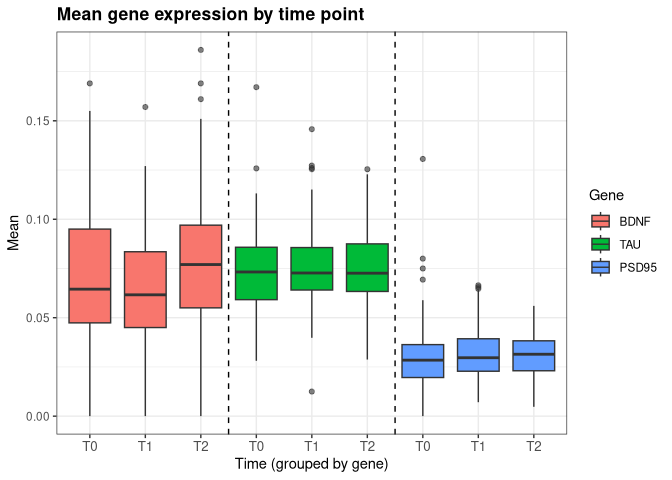

In [ ]:
#| label: fig-boxplots-genes
#| fig-cap: "Boxplots of gene expression means by time point and gene."

library(dplyr)
library(ggplot2)

all_long <- bind_rows(
  bdnf_mean  %>% mutate(Gene = "BDNF"),
  tau_mean   %>% mutate(Gene = "TAU"),
  psd95_mean %>% mutate(Gene = "PSD95")
) %>%
  mutate(
    Zeitpunkt = factor(Zeitpunkt, levels = c("T0","T1","T2")),
    Gene = factor(Gene, levels = c("BDNF","TAU","PSD95")),
    GeneTime = factor(
      paste(Gene, Zeitpunkt, sep = "_"),
      levels = c("BDNF_T0","BDNF_T1","BDNF_T2",
                 "TAU_T0","TAU_T1","TAU_T2",
                 "PSD95_T0","PSD95_T1","PSD95_T2")
    )
  )

x <- library(dplyr)
library(ggplot2)

all_long <- bind_rows(
  bdnf_mean  %>% mutate(Gene = "BDNF"),
  tau_mean   %>% mutate(Gene = "TAU"),
  psd95_mean %>% mutate(Gene = "PSD95")
) %>%
  mutate(
    Zeitpunkt = factor(Zeitpunkt, levels = c("T0","T1","T2")),
    Gene = factor(Gene, levels = c("BDNF","TAU","PSD95")),
    GeneTime = factor(
      paste(Gene, Zeitpunkt, sep = "_"),
      levels = c("BDNF_T0","BDNF_T1","BDNF_T2",
                 "TAU_T0","TAU_T1","TAU_T2",
                 "PSD95_T0","PSD95_T1","PSD95_T2")
    )
  )

x <- ggplot(all_long, aes(x = GeneTime, y = Mean, fill = Gene)) +
  geom_boxplot(na.rm = TRUE, outlier.alpha = 0.6) +
  geom_vline(xintercept = c(3.5, 6.5), linetype = 2) +
  scale_x_discrete(labels = rep(c("T0","T1","T2"), 3)) +
  labs(title = "Mean gene expression by time point", x = "Time (grouped by gene)", y = "Mean", fill = "Gene") +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 10),
    plot.title = element_text(face = "bold")
  )

x

## Time Differences in Mean Values

In [ ]:
#| label: time-differences
# Methylierung: PSD95 < Tau < BDNF

tapply(bdnf_mean$Mean, bdnf_mean$Zeitpunkt, mean, na.rm = TRUE) # T0 > T1 < T2 (T0 < T2)

        T0         T1         T2 
0.06991766 0.06213866 0.07886025 

   T0    T1    T2 
0.030 0.025 0.040 

        T0         T1         T2 
0.07346318 0.07632020 0.07604121 

   T0    T1    T2 
0.020 0.020 0.015 

        T0         T1         T2 
0.02978670 0.03197377 0.03078094 

T0 T1 T2 
 0  0  0 

-   Die Gene sind allgemein eher gering methyliert (Mean \< 0,08, Median
    \< 0,04).
-   Dabei ist PSD95 am geringsten und BDNF am höchsten metyhyliert.
-   Bei BDNF zeigt sich, dass sich die Mittelwerte (Arithmetisch und
    Median) von T0 zu T1 leicht absenken und zu T2 wieder über das
    Niveau von T0 ansteigen.
-   Bei Tau steigt das arithmetische Mittel der Methylierung leicht von
    T0 zu T1 und hält das Niveau bei T2.
-   Bei PSD95 verbleibt der Median der Methylierun gleichbleibend bei 0,
    während das arithmetische Mittel der Methylierung von T0 zu T1
    steigt aber bei T2 wieder auf das Ausgangsniveau zurückfällt.

## Important Point and Interval Estimators

In [ ]:
#| label: descriptives-wide

# Describe the wide format datasets
## BDNF
describe(bdnf_mean_wide)

          vars   n   mean    sd median trimmed   mad  min    max  range  skew
ID           1 144 108.17 62.41 121.50  109.68 80.80  1.0 202.00 201.00 -0.23
Standort     2 144   0.62  0.49   1.00    0.66  0.00  0.0   1.00   1.00 -0.51
Gruppe*      3 144   1.47  0.50   1.00    1.46  0.00  1.0   2.00   1.00  0.14
Sex*         4 144   1.42  0.50   1.00    1.41  0.00  1.0   2.00   1.00  0.31
Age_start    5 144  69.58  3.51  69.00   69.37  2.97 62.0  78.00  16.00  0.55
CogTel       6 144  31.77  7.23  32.15   31.76  8.52 15.5  49.20  33.70  0.00
T0           7 140   0.07  0.03   0.06    0.07  0.04  0.0   0.17   0.17  0.29
T1           8 122   0.06  0.03   0.06    0.06  0.03  0.0   0.16   0.16  0.06
T2           9  97   0.08  0.04   0.08    0.08  0.03  0.0   0.19   0.19  0.27
          kurtosis   se
ID           -1.36 5.20
Standort     -1.75 0.04
Gruppe*      -1.99 0.04
Sex*         -1.92 0.04
Age_start    -0.47 0.29
CogTel       -0.77 0.60
T0           -0.30 0.00
T1            0.18 0.00
T2  

          vars   n   mean    sd median trimmed   mad  min    max  range  skew
ID           1 144 108.17 62.41 121.50  109.68 80.80  1.0 202.00 201.00 -0.23
Standort     2 144   0.62  0.49   1.00    0.66  0.00  0.0   1.00   1.00 -0.51
Gruppe*      3 144   1.47  0.50   1.00    1.46  0.00  1.0   2.00   1.00  0.14
Sex*         4 144   1.42  0.50   1.00    1.41  0.00  1.0   2.00   1.00  0.31
Age_start    5 144  69.58  3.51  69.00   69.37  2.97 62.0  78.00  16.00  0.55
CogTel       6 144  31.77  7.23  32.15   31.76  8.52 15.5  49.20  33.70  0.00
T0           7 140   0.04  0.04   0.03    0.03  0.04  0.0   0.18   0.18  1.14
T1           8 122   0.03  0.03   0.03    0.03  0.04  0.0   0.12   0.12  0.86
T2           9  97   0.05  0.04   0.04    0.04  0.04  0.0   0.21   0.21  1.52
          kurtosis   se
ID           -1.36 5.20
Standort     -1.75 0.04
Gruppe*      -1.99 0.04
Sex*         -1.92 0.04
Age_start    -0.47 0.29
CogTel       -0.77 0.60
T0            0.78 0.00
T1           -0.04 0.00
T2  

          vars   n   mean    sd median trimmed   mad   min    max  range  skew
ID           1 145 108.39 62.25 122.00  109.95 80.06  1.00 202.00 201.00 -0.24
Standort     2 145   1.63  0.49   2.00    1.66  0.00  1.00   2.00   1.00 -0.52
Gruppe*      3 145   1.47  0.50   1.00    1.46  0.00  1.00   2.00   1.00  0.12
Sex*         4 145   1.43  0.50   1.00    1.41  0.00  1.00   2.00   1.00  0.29
Age_start    5 145  69.57  3.50  69.00   69.36  2.97 62.00  78.00  16.00  0.56
CogTel       6 145  31.77  7.20  32.40   31.77  8.60 15.50  49.20  33.70 -0.01
T0           7 142   0.07  0.02   0.07    0.07  0.02  0.03   0.17   0.14  0.79
T1           8 123   0.08  0.02   0.07    0.07  0.02  0.01   0.15   0.13  0.60
T2           9  97   0.08  0.02   0.07    0.08  0.02  0.03   0.13   0.10  0.37
          kurtosis   se
ID           -1.35 5.17
Standort     -1.74 0.04
Gruppe*      -2.00 0.04
Sex*         -1.93 0.04
Age_start    -0.46 0.29
CogTel       -0.75 0.60
T0            2.54 0.00
T1            1.01

          vars   n   mean    sd median trimmed   mad  min    max  range  skew
ID           1 145 108.39 62.25 122.00  109.95 80.06  1.0 202.00 201.00 -0.24
Standort     2 145   1.63  0.49   2.00    1.66  0.00  1.0   2.00   1.00 -0.52
Gruppe*      3 145   1.47  0.50   1.00    1.46  0.00  1.0   2.00   1.00  0.12
Sex*         4 145   1.43  0.50   1.00    1.41  0.00  1.0   2.00   1.00  0.29
Age_start    5 145  69.57  3.50  69.00   69.36  2.97 62.0  78.00  16.00  0.56
CogTel       6 145  31.77  7.20  32.40   31.77  8.60 15.5  49.20  33.70 -0.01
T0           7 142   0.02  0.01   0.02    0.02  0.01  0.0   0.05   0.05  0.19
T1           8 123   0.02  0.02   0.02    0.02  0.01  0.0   0.12   0.12  1.93
T2           9  97   0.02  0.01   0.01    0.02  0.01  0.0   0.06   0.06  0.69
          kurtosis   se
ID           -1.35 5.17
Standort     -1.74 0.04
Gruppe*      -2.00 0.04
Sex*         -1.93 0.04
Age_start    -0.46 0.29
CogTel       -0.75 0.60
T0           -0.95 0.00
T1            8.21 0.00
T2  

          vars   n   mean    sd median trimmed   mad   min    max  range  skew
ID           1 145 108.39 62.25 122.00  109.95 80.06  1.00 202.00 201.00 -0.24
Standort     2 145   1.63  0.49   2.00    1.66  0.00  1.00   2.00   1.00 -0.52
Gruppe*      3 145   1.47  0.50   1.00    1.46  0.00  1.00   2.00   1.00  0.12
Sex*         4 145   1.43  0.50   1.00    1.41  0.00  1.00   2.00   1.00  0.29
Age_start    5 145  69.57  3.50  69.00   69.36  2.97 62.00  78.00  16.00  0.56
CogTel       6 145  31.77  7.20  32.40   31.77  8.60 15.50  49.20  33.70 -0.01
T0           7 139   0.03  0.02   0.03    0.03  0.01  0.00   0.13   0.13  2.27
T1           8 122   0.03  0.01   0.03    0.03  0.01  0.01   0.07   0.06  0.68
T2           9  96   0.03  0.01   0.03    0.03  0.01  0.00   0.06   0.05 -0.09
          kurtosis   se
ID           -1.35 5.17
Standort     -1.74 0.04
Gruppe*      -2.00 0.04
Sex*         -1.93 0.04
Age_start    -0.46 0.29
CogTel       -0.75 0.60
T0           11.51 0.00
T1            0.03

          vars   n   mean    sd median trimmed   mad  min    max  range  skew
ID           1 145 108.39 62.25  122.0  109.95 80.06  1.0 202.00 201.00 -0.24
Standort     2 145   1.63  0.49    2.0    1.66  0.00  1.0   2.00   1.00 -0.52
Gruppe*      3 145   1.47  0.50    1.0    1.46  0.00  1.0   2.00   1.00  0.12
Sex*         4 145   1.43  0.50    1.0    1.41  0.00  1.0   2.00   1.00  0.29
Age_start    5 145  69.57  3.50   69.0   69.36  2.97 62.0  78.00  16.00  0.56
CogTel       6 145  31.77  7.20   32.4   31.77  8.60 15.5  49.20  33.70 -0.01
T0           7 139   0.00  0.01    0.0    0.00  0.00  0.0   0.05   0.05  3.65
T1           8 122   0.00  0.01    0.0    0.00  0.00  0.0   0.06   0.06  3.28
T2           9  96   0.00  0.00    0.0    0.00  0.00  0.0   0.02   0.02  5.48
          kurtosis   se
ID           -1.35 5.17
Standort     -1.74 0.04
Gruppe*      -2.00 0.04
Sex*         -1.93 0.04
Age_start    -0.46 0.29
CogTel       -0.75 0.60
T0           13.50 0.00
T1           12.12 0.00
T2  

## Plotting EDA

### Boxplots

In [ ]:
eda_bdnf <- cpg
bdnfcols_to_modify <- 5:14

eda_tau <- cpg
taucols_to_modify <- 19:67

eda_psd95 <- cpg
psd95cols_to_modify <- 74:116

# Remove the suffix 'BDNF' from the column names in columns 5 to 14
colnames(eda_bdnf)[bdnfcols_to_modify] <- sub("BDNF$", "", colnames(eda_bdnf)[bdnfcols_to_modify])

# remove "Tau
colnames(eda_tau)[taucols_to_modify] <- sub("Tau$", "", colnames(eda_tau)[taucols_to_modify])

#remove PSD
colnames(eda_psd95)[psd95cols_to_modify] <- sub("PSD95$", "", colnames(eda_psd95)[psd95cols_to_modify])

# View the updated column names
print(colnames(eda_bdnf[c(5:14)]))

 [1] "m148." "m111." "m087." "m066." "m058." "m039." "m035." "m024." "p018."
[10] "p020."

 [1] "m337."   "m331."   "m323."   "m315."   "m310."   "m306."   "m300."  
 [8] "m293."   "m287."   "m277."   "m249."   "m219."   "m210."   "m207."  
[15] "m187."   "m181."   "m172."   "m152."   "m147."   "m111.1." "m109."  
[22] "m105."   "m100."   "m95."    "m93."    "m91."    "m87."    "m85."   
[29] "m80."    "m73."    "m70."    "m68."    "m58."    "m53."    "m41."   
[36] "m39."    "m28."    "m25."    "m16."    "m11."    "m4."     "m1."    
[43] "p3."     "p7."     "p11."    "p19."    "p23."    "p25."    "p27."   

 [1] "m465.PSD95" "m418.PSD95" "m405."      "m400."      "m395."     
 [6] "m392."      "m349."      "m340."      "m329."      "m326."     
[11] "m294."      "m291."      "m284."      "m282."      "m254."     
[16] "m249.1."    "m236."      "m226."      "m199."      "m193."     
[21] "m176."      "m165."      "m163."      "m155."      "m150."     
[26] "m124."      "m113."      "m92."       "m83."       "m77."      
[31] "m69."       "m49."       "m35."       "m31."       "m28.1."    
[36] "m24."       "m18."       "m11.1."     "p23.1."     "p31."      
[41] "p36."       "p60."       "p91."       "p95."       "p122."     

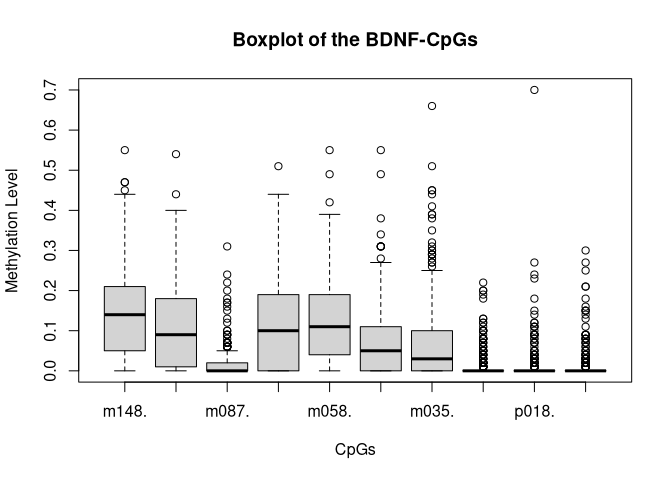

In [ ]:
#| label: fig-boxplot-cpg-bdnf

boxplot(eda_bdnf[, c(5:14)], 
        xlab = "CpGs", 
        ylab = "Methylation Level", 
        main = "Boxplot of the BDNF-CpGs")

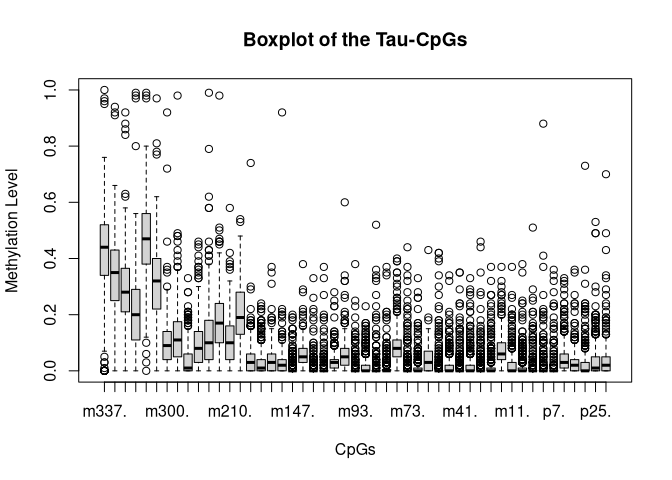

In [ ]:
#| label: fig-boxplot-cpg-tau

boxplot(eda_tau[, c(19:67)], 
        xlab = "CpGs", 
        ylab = "Methylation Level", 
        main = "Boxplot of the Tau-CpGs")

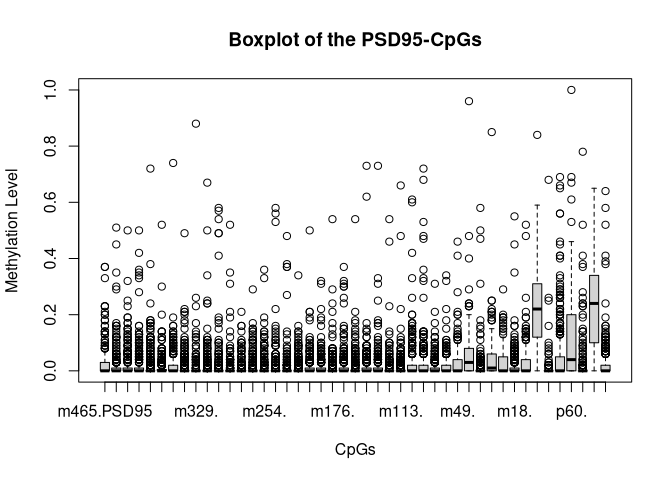

In [ ]:
#| label: fig-boxplot-cpg-psd95

boxplot(eda_psd95[, c(72:116)], 
        xlab = "CpGs", 
        ylab = "Methylation Level", 
        main = "Boxplot of the PSD95-CpGs")

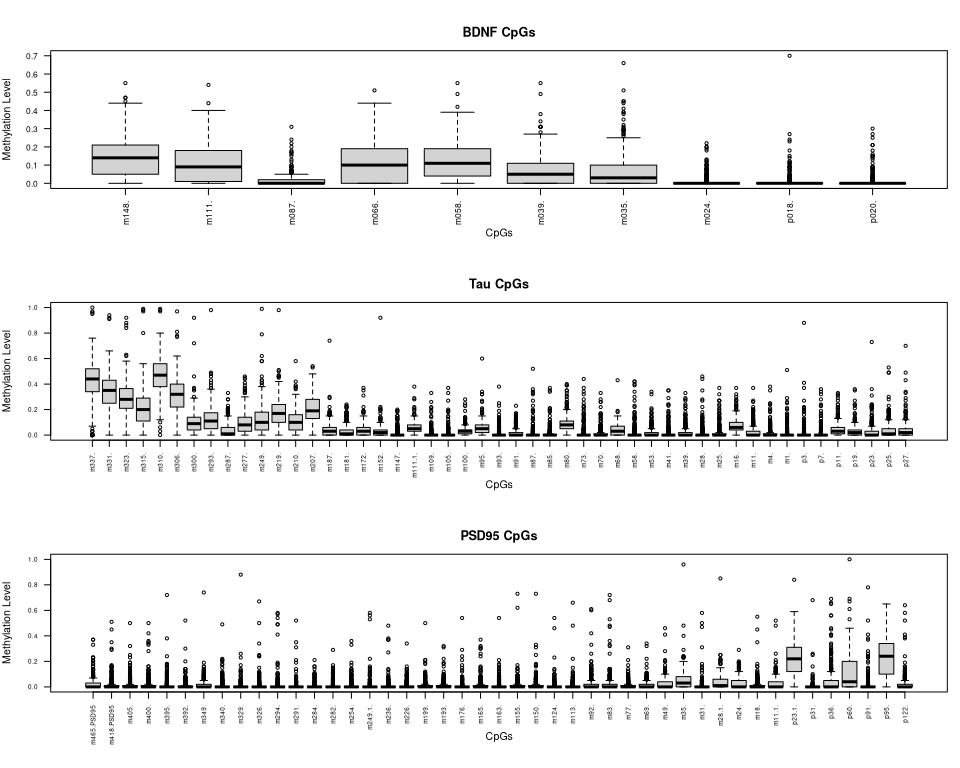

In [ ]:
#| label: fig-boxplots-cpg-all
#| fig-cap: "Boxplots of CpG methylation levels for BDNF, Tau, and PSD95."
#| fig-width: 10
#| fig-height: 8

op <- par(no.readonly = TRUE)
par(mfrow = c(3, 1), mar = c(6, 4, 3, 1), oma = c(0, 0, 1, 0))

boxplot(eda_bdnf[, 5:14],
        xlab = "CpGs", ylab = "Methylation Level",
        main = "BDNF CpGs",
        las = 2, cex.axis = 0.8)

boxplot(eda_tau[, 19:67],
        xlab = "CpGs", ylab = "Methylation Level",
        main = "Tau CpGs",
        las = 2, cex.axis = 0.6)

boxplot(eda_psd95[, 72:116],
        xlab = "CpGs", ylab = "Methylation Level",
        main = "PSD95 CpGs",
        las = 2, cex.axis = 0.6)

par(op)

#### Zoom to methlyated CpGs in Tau and PSD95

siehe “131124_TBM mit Martin.qmd” ab Zeile 1074

### Violinplots

Siehe “Python_violinplots.ipynb”

### Lineplots

In [ ]:
#| label: helpers-cpg-long
#| include: false

# Helper: convert wide CpG data to long format and keep CpG order

make_long <- function(df, cols) {
levs <- names(df)[cols]
df %>%
pivot_longer(cols = all_of(cols), names_to = "CpG", values_to = "Expression") %>%
mutate(
CpG        = factor(CpG, levels = levs),
Expression = suppressWarnings(as.numeric(Expression))
)
}

# Helper: median + IQR per CpG

plot_median_iqr <- function(long_df, title) {
long_df %>%
group_by(CpG) %>%
summarise(
q25   = quantile(Expression, 0.25, na.rm = TRUE),
median= median(Expression, na.rm = TRUE),
q75   = quantile(Expression, 0.75, na.rm = TRUE),
.groups = "drop"
) %>%
ggplot(aes(CpG)) +
geom_ribbon(aes(ymin = q25, ymax = q75, group = 1), alpha = 0.25) +
geom_line(aes(y = median, group = 1), linewidth = 1) +
geom_point(aes(y = median), size = 2) +
labs(title = title, x = "CpG", y = "Expression") +
theme_minimal() +
theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

# Helper: decile profiles (10 typical lines)

plot_deciles <- function(long_df, id_col, title) {
idq <- enquo(id_col)

id_deciles <- long_df %>%
group_by(!!idq) %>%
summarise(id_mean = mean(Expression, na.rm = TRUE), .groups = "drop") %>%
mutate(decile = ntile(id_mean, 10))

decile_cpgl <- long_df %>%
inner_join(id_deciles, by = as_name(idq)) %>%
group_by(decile, CpG) %>%
summarise(median = median(Expression, na.rm = TRUE), .groups = "drop")

ggplot(decile_cpgl,
aes(CpG, median, group = factor(decile), color = factor(decile))) +
geom_line(linewidth = 1) +
geom_point(size = 1.5) +
labs(title = title, x = "CpG", y = "Median expression", color = "Decile") +
theme_minimal() +
theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

# Helper: k-means centroid profiles (~k typical lines)

plot_kmeans <- function(long_df, id_col, k = 8, title = NULL) {
idq <- enquo(id_col)

wide <- long_df %>%
pivot_wider(
id_cols    = !!idq,
names_from = CpG,
values_from= Expression,
values_fn  = ~ median(.x, na.rm = TRUE),
values_fill= NA_real_
)

stopifnot(!any(sapply(wide, is.list)))

mat <- wide %>% select(-!!idq) %>% data.matrix()
for (j in seq_len(ncol(mat))) {
mj <- median(mat[, j], na.rm = TRUE)
mat[is.na(mat[, j]), j] <- mj
}

set.seed(1)
km <- kmeans(scale(mat), centers = k, nstart = 25)

centers <- as.data.frame(km$centers) %>%
rownames_to_column("cluster") %>%
pivot_longer(-cluster, names_to = "CpG", values_to = "Expression") %>%
mutate(
cluster = factor(cluster),
CpG     = factor(CpG, levels = names(wide)[-1])
)

ggplot(centers, aes(CpG, Expression, group = cluster, color = cluster)) +
geom_line(linewidth = 1.1) +
geom_point(size = 1.4) +
labs(
title = ifelse(is.null(title),
"Cluster centroid profiles (scaled)", title),
x = "CpG", y = "Scaled expression", color = "Cluster"
) +
theme_minimal() +
theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

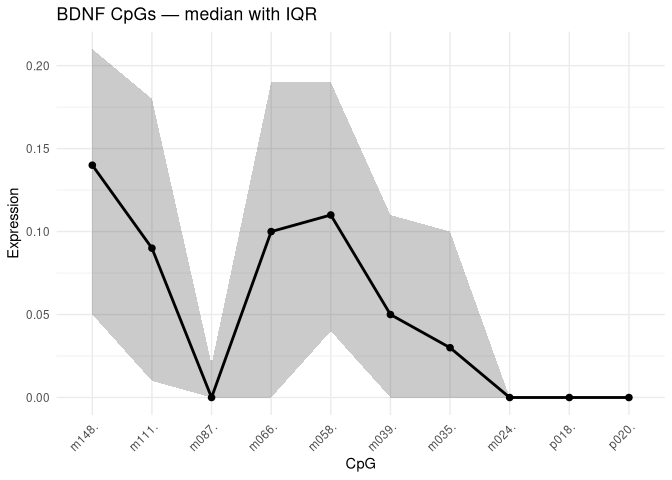

(`geom_line()`).

(`geom_point()`).

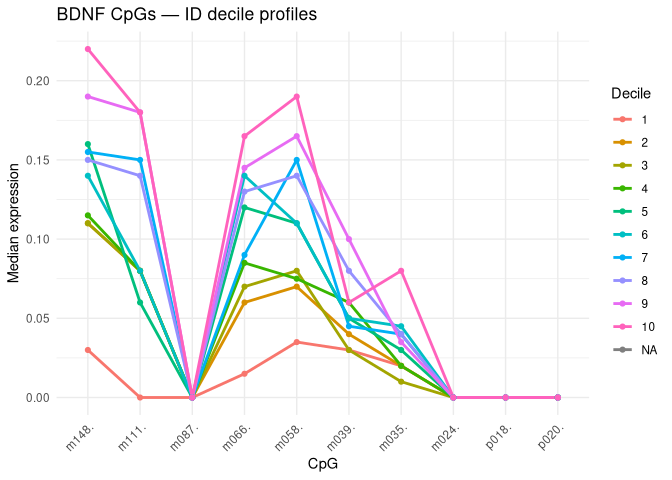

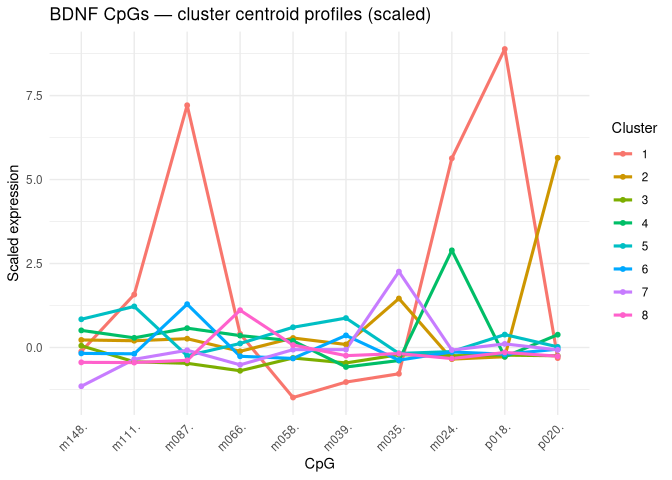

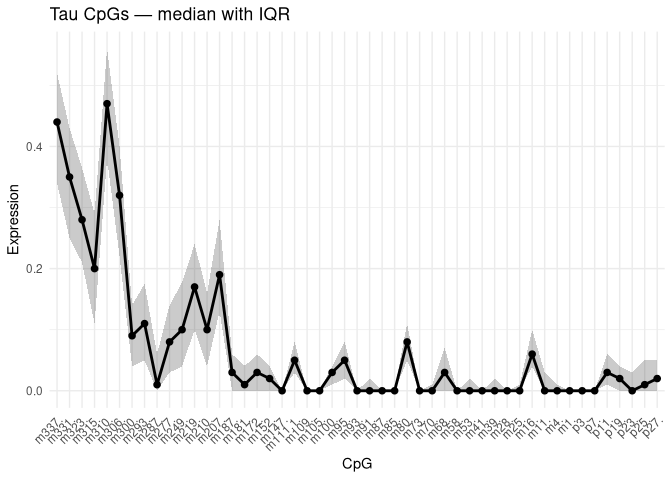

(`geom_line()`).

(`geom_point()`).

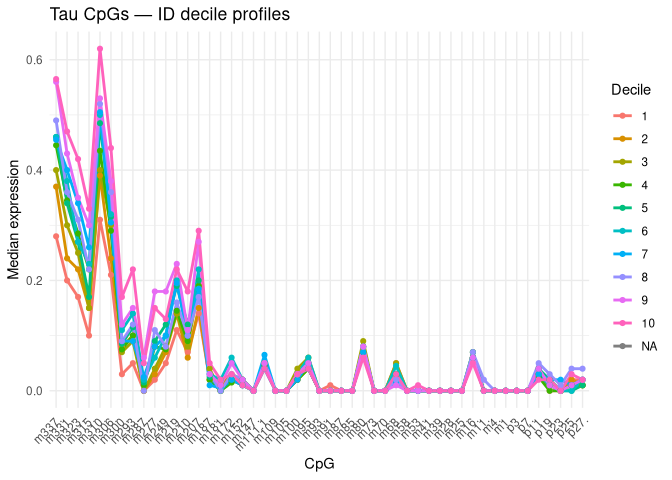

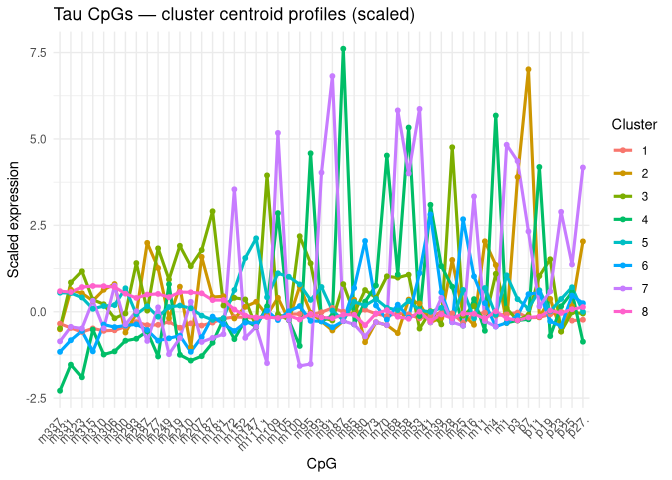

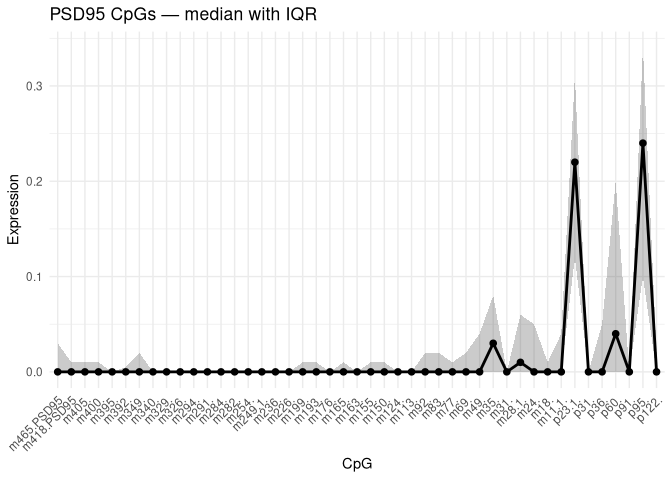

(`geom_line()`).

(`geom_point()`).

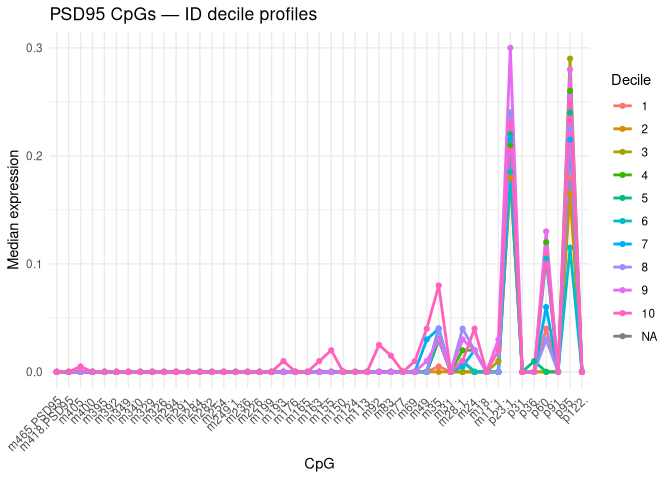

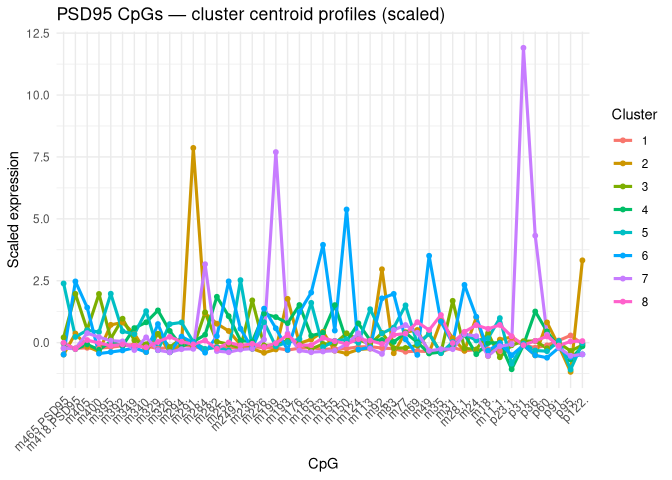

In [ ]:
#| label: lineplots-cpg

bdnf_cols <- 5:14
tau_cols  <- 19:67
psd_cols  <- 72:116


# Long versions (CpG x person)

bdnf_cpg_long  <- make_long(eda_bdnf,  bdnf_cols)
tau_cpg_long   <- make_long(eda_tau,   tau_cols)
psd95_cpg_long <- make_long(eda_psd95, psd_cols)

# BDNF

plot_median_iqr(bdnf_cpg_long, "BDNF CpGs — median with IQR")

### Lineplots by Zeitpunkt

(`geom_line()`).

(`geom_point()`).

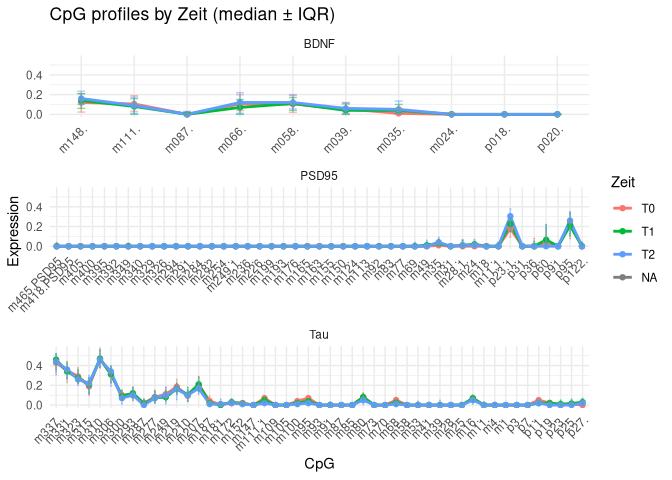

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

(`geom_line()`).

(`geom_point()`).

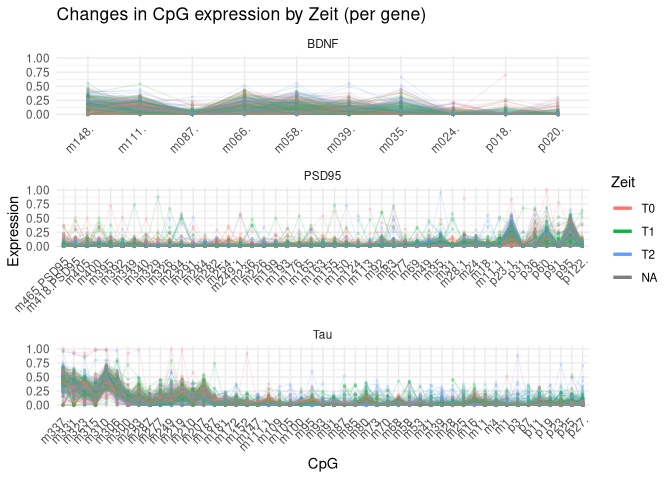

In [ ]:
#| label: lineplots-zeit

# Column ranges reused

bdnf_cols <- 5:14
tau_cols  <- 19:67
psd_cols  <- 72:116

bdnf_levels <- names(eda_bdnf)[bdnf_cols]
tau_levels  <- names(eda_tau)[tau_cols]
psd_levels  <- names(eda_psd95)[psd_cols]

bdnf_time_long <- eda_bdnf %>%
pivot_longer(all_of(bdnf_cols), names_to = "CpG", values_to = "Expression") %>%
transmute(
Gene       = "BDNF",
ID         = ID.BDNF,
Zeit       = factor(Zeitpunkt.BDNF),
CpG        = factor(CpG, levels = bdnf_levels),
Expression = suppressWarnings(as.numeric(Expression))
)

tau_time_long <- eda_tau %>%
pivot_longer(all_of(tau_cols), names_to = "CpG", values_to = "Expression") %>%
transmute(
Gene       = "Tau",
ID         = ID.Tau,
Zeit       = factor(Zeit.Tau),
CpG        = factor(CpG, levels = tau_levels),
Expression = suppressWarnings(as.numeric(Expression))
)

psd95_time_long <- eda_psd95 %>%
pivot_longer(all_of(psd_cols), names_to = "CpG", values_to = "Expression") %>%
transmute(
Gene       = "PSD95",
ID         = ID.PSD95,
Zeit       = factor(Zeitpunkt.PSD95),
CpG        = factor(CpG, levels = psd_levels),
Expression = suppressWarnings(as.numeric(Expression))
)

all_time_long <- bind_rows(bdnf_time_long, tau_time_long, psd95_time_long)

# A) Zeit summary per gene: median ± IQR

zeit_sum <- all_time_long %>%
group_by(Gene, Zeit, CpG) %>%
summarise(
q25   = quantile(Expression, 0.25, na.rm = TRUE),
median= median(Expression, na.rm = TRUE),
q75   = quantile(Expression, 0.75, na.rm = TRUE),
.groups = "drop"
)

ggplot(zeit_sum, aes(CpG, median, group = Zeit, color = Zeit)) +
geom_line(linewidth = 1) +
geom_point(size = 1.6) +
geom_errorbar(aes(ymin = q25, ymax = q75), width = 0.15, alpha = 0.5) +
facet_wrap(~ Gene, scales = "free_x", ncol = 1) +
labs(title = "CpG profiles by Zeit (median ± IQR)",
x = "CpG", y = "Expression") +
theme_minimal() +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

## CpG summary table

### BDNF

In [ ]:
#| label: cpg-summary-bdnf

cpgl_table_bdnf <- bdnf_cpg_long %>%
group_by(CpG) %>%
summarise(
n      = n(),
mean   = mean(Expression, na.rm = TRUE),
sd     = sd(Expression, na.rm = TRUE),
median = median(Expression, na.rm = TRUE),
q25    = quantile(Expression, 0.25, na.rm = TRUE),
q75    = quantile(Expression, 0.75, na.rm = TRUE),
min    = min(Expression, na.rm = TRUE),
max    = max(Expression, na.rm = TRUE),
.groups = "drop"
)

print(cpgl_table_bdnf, n = Inf)

# A tibble: 10 × 9
   CpG       n   mean     sd median   q25   q75   min   max
   <fct> <int>  <dbl>  <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
 1 m148.   375 0.145  0.113    0.14  0.05  0.21     0  0.55
 2 m111.   375 0.109  0.0982   0.09  0.01  0.18     0  0.54
 3 m087.   375 0.0185 0.0381   0     0     0.02     0  0.31
 4 m066.   375 0.119  0.112    0.1   0     0.19     0  0.51
 5 m058.   375 0.123  0.103    0.11  0.04  0.19     0  0.55
 6 m039.   375 0.0736 0.0833   0.05  0     0.11     0  0.55
 7 m035.   375 0.0706 0.100    0.03  0     0.1      0  0.66
 8 m024.   375 0.0120 0.0326   0     0     0        0  0.22
 9 p018.   375 0.0123 0.0491   0     0     0        0  0.7 
10 p020.   375 0.0119 0.0389   0     0     0        0  0.3 

### Tau

In [ ]:
#| label: cpg-summary-tau

cpgl_table_tau <- tau_cpg_long %>%
group_by(CpG) %>%
summarise(
n = n(),
mean = mean(Expression, na.rm = TRUE),
sd = sd(Expression, na.rm = TRUE),
median = median(Expression, na.rm = TRUE),
q25 = quantile(Expression, 0.25, na.rm = TRUE),
q75 = quantile(Expression, 0.75, na.rm = TRUE),
min = min(Expression, na.rm = TRUE),
max = max(Expression, na.rm = TRUE),
.groups = "drop"
)

print(cpgl_table_tau, n = Inf)

# A tibble: 49 × 9
   CpG         n   mean     sd median   q25    q75   min   max
   <fct>   <int>  <dbl>  <dbl>  <dbl> <dbl>  <dbl> <dbl> <dbl>
 1 m337.     375 0.423  0.170    0.44  0.34 0.52       0  1   
 2 m331.     375 0.337  0.152    0.35  0.25 0.43       0  0.94
 3 m323.     375 0.288  0.134    0.28  0.21 0.365      0  0.92
 4 m315.     375 0.210  0.144    0.2   0.11 0.29       0  0.99
 5 m310.     375 0.468  0.139    0.47  0.38 0.56       0  0.99
 6 m306.     375 0.314  0.135    0.32  0.22 0.4        0  0.97
 7 m300.     375 0.102  0.0931   0.09  0.04 0.14       0  0.92
 8 m293.     375 0.129  0.107    0.11  0.05 0.175      0  0.98
 9 m287.     375 0.0393 0.0569   0.01  0    0.06       0  0.33
10 m277.     375 0.0964 0.0900   0.08  0.03 0.14       0  0.46
11 m249.     375 0.123  0.119    0.1   0.04 0.178      0  0.99
12 m219.     375 0.177  0.115    0.17  0.1  0.24       0  0.98
13 m210.     375 0.109  0.0885   0.1   0.04 0.16       0  0.58
14 m207.     375 0.202  0.112    0.1

### PSD95

In [ ]:
#| label: cpg-summary-psd95

cpgl_table_psd95 <- psd95_cpg_long %>%
group_by(CpG) %>%
summarise(
n      = n(),
mean   = mean(Expression, na.rm = TRUE),
sd     = sd(Expression, na.rm = TRUE),
median = median(Expression, na.rm = TRUE),
q25    = quantile(Expression, 0.25, na.rm = TRUE),
q75    = quantile(Expression, 0.75, na.rm = TRUE),
min    = min(Expression, na.rm = TRUE),
max    = max(Expression, na.rm = TRUE),
.groups = "drop"
)

print(cpgl_table_psd95, n = Inf)

# A tibble: 45 × 9
   CpG            n    mean     sd median   q25   q75   min   max
   <fct>      <int>   <dbl>  <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
 1 m465.PSD95   375 0.0252  0.0554   0     0    0.03      0  0.37
 2 m418.PSD95   375 0.0203  0.0592   0     0    0.01      0  0.51
 3 m405.        375 0.0204  0.0526   0     0    0.01      0  0.5 
 4 m400.        375 0.0232  0.0628   0     0    0.01      0  0.5 
 5 m395.        375 0.0191  0.0594   0     0    0         0  0.72
 6 m392.        375 0.0132  0.0425   0     0    0.005     0  0.52
 7 m349.        375 0.0194  0.0538   0     0    0.02      0  0.74
 8 m340.        375 0.0150  0.0439   0     0    0         0  0.49
 9 m329.        375 0.0108  0.0575   0     0    0         0  0.88
10 m326.        375 0.0160  0.0595   0     0    0         0  0.67
11 m294.        375 0.0173  0.0741   0     0    0         0  0.58
12 m291.        375 0.0108  0.0452   0     0    0         0  0.52
13 m284.        375 0.00821 0.0261   0     0    0        

## Cross-Tabulations and Chi-Squared Tests

### BDNF

In [ ]:
#| label: bdnf-wide-clean

bdnf_labels <- read.table(header = TRUE, text = "
name      label
ID        'Participant ID'
Standort  'Site'
Gruppe    'Group'
Sex       'Sex'
Age_start 'Age at baseline (years)'
CogTel    'CogTel total score'
T0        'BDNF at T0'
T1        'BDNF at T1'
T2        'BDNF at T2'
")

bdnf2 <- bdnf_mean_wide %>%
mutate(
ID = as.integer(ID),
Standort = case_when(
Standort %in% c(0, "0") ~ "Site_0",
Standort %in% c(1, "1") ~ "Site_1",
TRUE ~ as.character(Standort)
),
Gruppe = dplyr::recode(Gruppe, "Controll" = "Control"),
Sex    = dplyr::recode(Sex,    "F" = "Female", "M" = "Male"),
across(c(Standort, Gruppe, Sex), ~ fct_infreq(as.factor(.x)))
) %>%
import_labels(bdnf_labels, name_from = "name", label_from = "label") %>%
as_tibble()

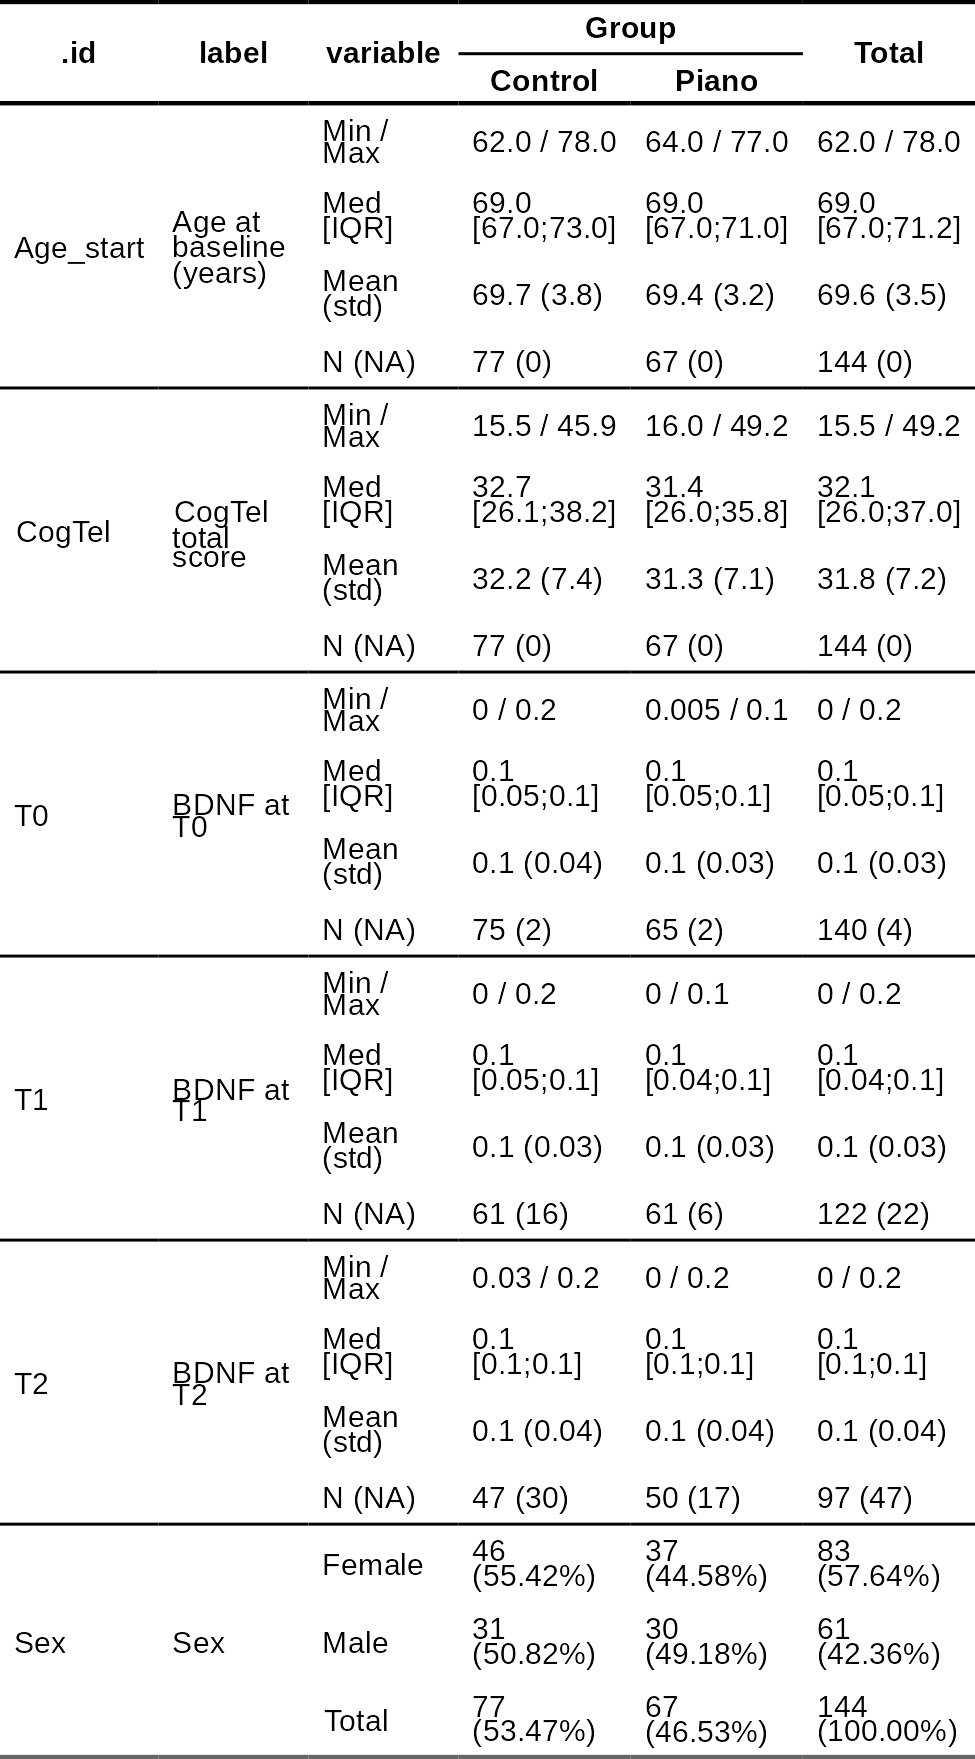

In [ ]:
#| label: bdnf-crosstable-group

crosstable(
bdnf2,
c(Age_start, CogTel, T0:T2, Sex),
by = Gruppe,
showNA= "ifany",
total = "both"
) %>%
as_flextable(keep_id = TRUE)

Warning in crosstable(bdnf_time_long, c(Age_start, CogTel, Sex, BDNF), by = Stratum, : Be aware that automatic global testing should only be done in an exploratory
context, as it would cause extensive alpha inflation otherwise.
This warning is displayed once every 8 hours.

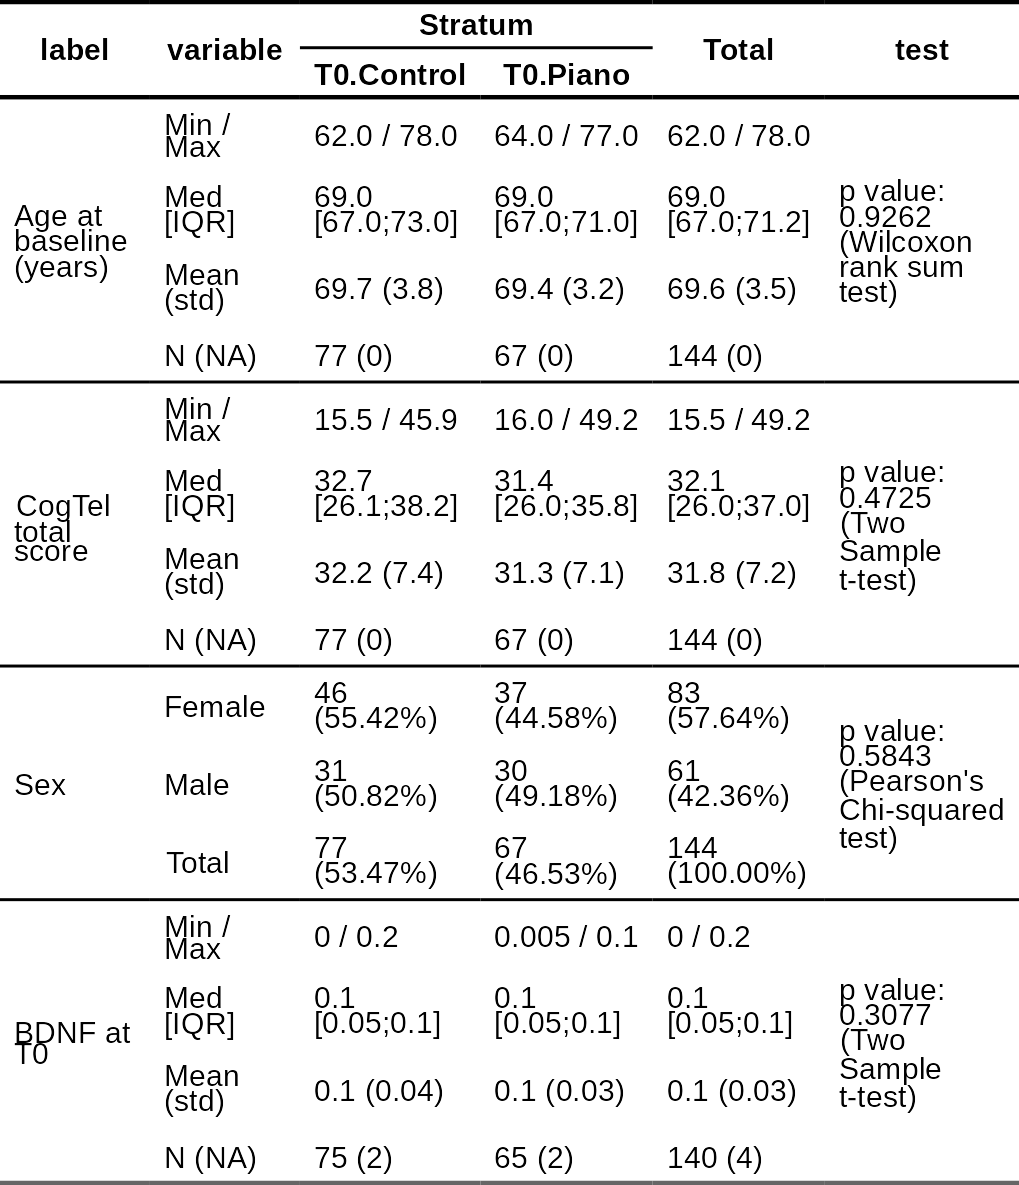

In [ ]:
#| label: bdnf-crosstable-strata

#Long by time, with Time*Group strata

bdnf_time_long <- bdnf2 %>%
pivot_longer(T0, names_to = "Time", values_to = "BDNF") %>%
mutate(
Time = factor(Time, levels = c("T0", "T1", "T2")),
Gruppe = factor(Gruppe),
ID = factor(ID),
Stratum= interaction(Time, Gruppe, drop = TRUE)
)

crosstable(
bdnf_time_long,
c(Age_start, CogTel, Sex, BDNF),
by = Stratum,
showNA= "ifany",
total = "both",
test = TRUE
) %>%
as_flextable()

In [ ]:
#| label: bdnf-sex-chi-square

tab <- with(bdnf2, table(Sex, Gruppe))
tab

        Gruppe
Sex      Control Piano
  Female      46    37
  Male        31    30


    Pearson's Chi-squared test with Yates' continuity correction

data:  tab
X-squared = 0.1429, df = 1, p-value = 0.7054

[1] 0.04558996


    2-sample test for equality of proportions with continuity correction

data:  c(tab["Male", "Control"], tab["Male", "Piano"]) out of c(colSums(tab)["Control"], colSums(tab)["Piano"])
X-squared = 0.1429, df = 1, p-value = 0.7054
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.2209109  0.1305833
sample estimates:
   prop 1    prop 2 
0.4025974 0.4477612 

### Tau

In [ ]:
#| label: tau-wide-clean

tau_labels <- read.table(header = TRUE, text = "
name      label
ID        'Participant ID'
Standort  'Site'
Gruppe    'Group'
Sex       'Sex'
Age_start 'Age at baseline (years)'
CogTel    'CogTel total score'
T0        'Tau at T0'
T1        'Tau at T1'
T2        'Tau at T2'
")

tau2 <- tau_mean_wide %>%
mutate(
ID = as.integer(ID),
Standort = case_when(
Standort %in% c(0, "0") ~ "Site_0",
Standort %in% c(1, "1") ~ "Site_1",
TRUE ~ as.character(Standort)
),
Gruppe = dplyr::recode(Gruppe, "Controll" = "Control"),
Sex    = dplyr::recode(Sex,    "F" = "Female", "M" = "Male"),
across(c(Standort, Gruppe, Sex), ~ fct_infreq(as.factor(.x)))
) %>%
import_labels(tau_labels, name_from = "name", label_from = "label") %>%
as_tibble()

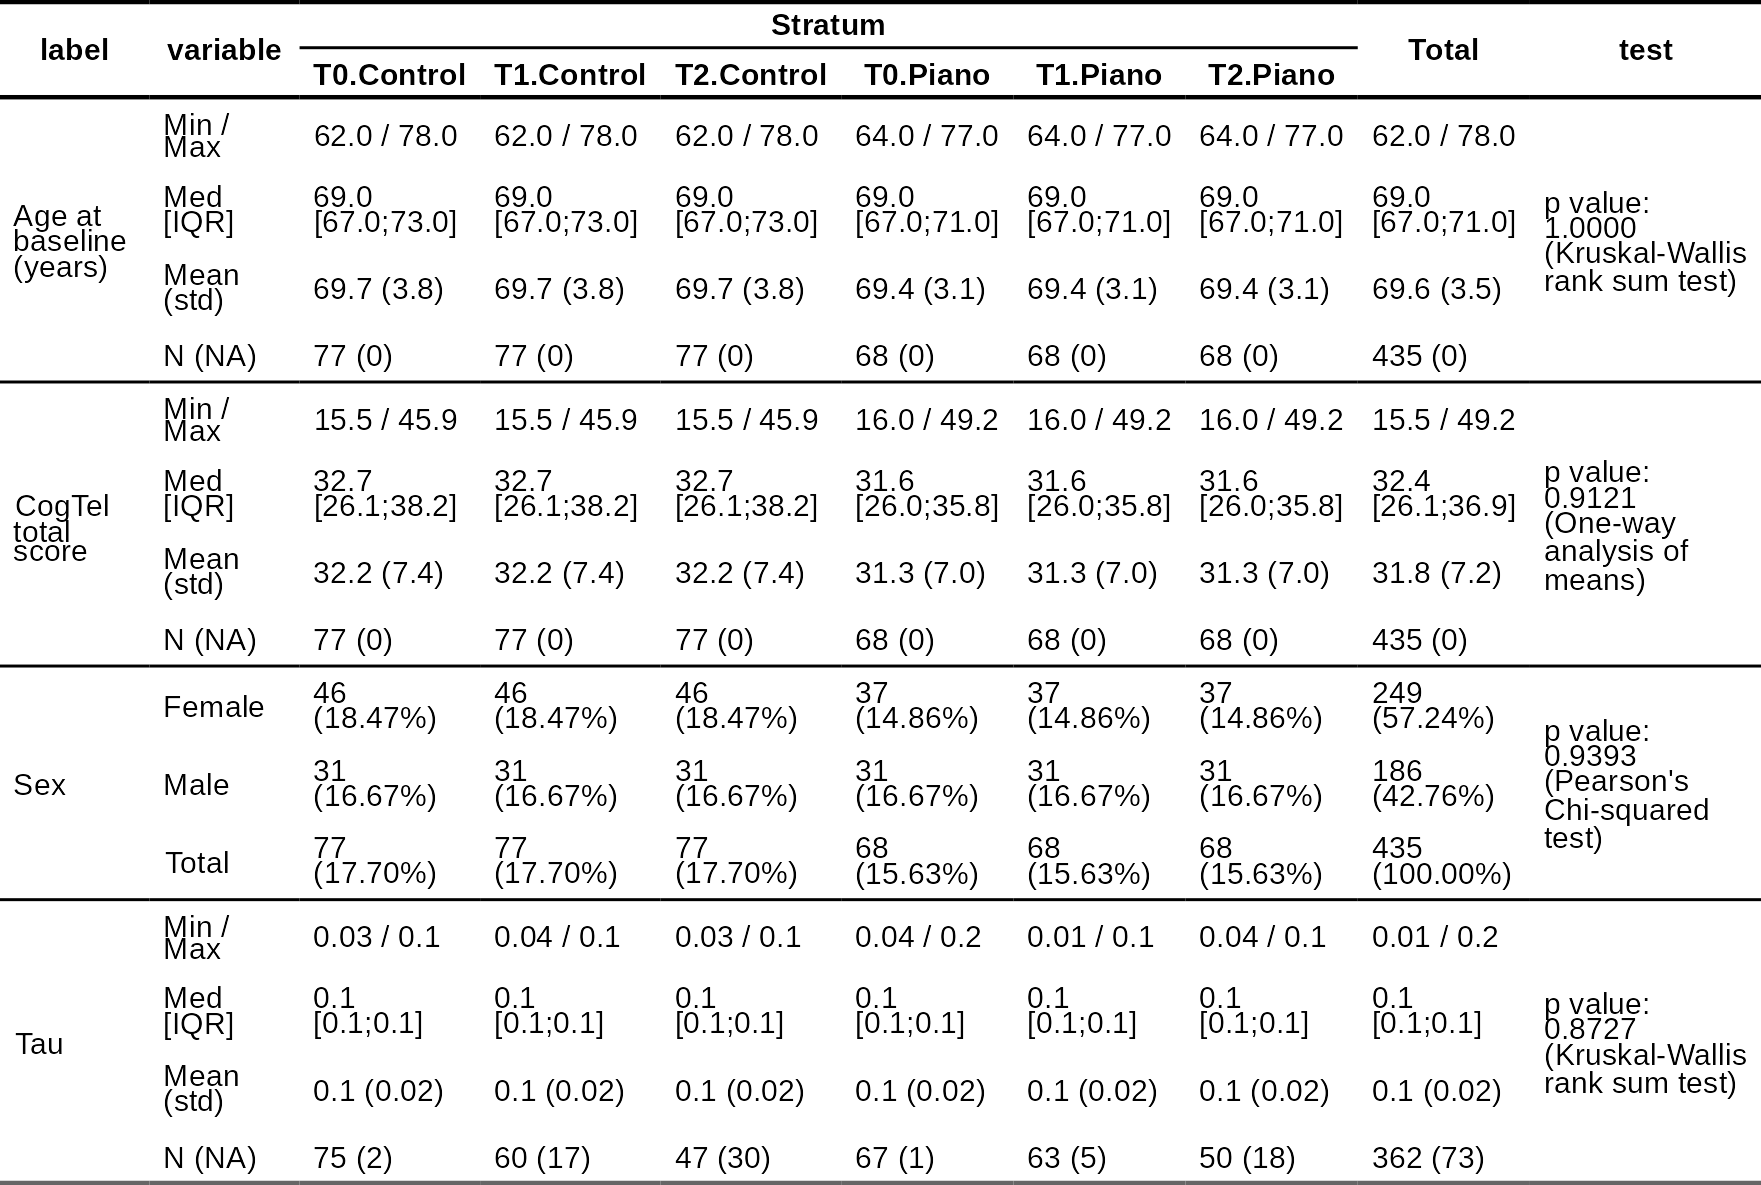

In [ ]:
#| label: tau-crosstable-strata

tau_time_long <- tau2 %>%
pivot_longer(T0:T2, names_to = "Time", values_to = "Tau") %>%
mutate(
Time   = factor(Time, levels = c("T0", "T1", "T2")),
Gruppe = factor(Gruppe),
ID     = factor(ID),
Stratum= interaction(Time, Gruppe, drop = TRUE)
)

crosstable(
tau_time_long,
c(Age_start, CogTel, Sex, Tau),
by    = Stratum,
showNA= "ifany",
total = "both",
test  = TRUE
) %>%
as_flextable()

### PSD95

In [ ]:
#| label: psd95-wide-clean

psd95_labels <- read.table(header = TRUE, text = "
name      label
ID        'Participant ID'
Standort  'Site'
Gruppe    'Group'
Sex       'Sex'
Age_start 'Age at baseline (years)'
CogTel    'CogTel total score'
T0        'PSD95 at T0'
T1        'PSD95 at T1'
T2        'PSD95 at T2'
")

psd952 <- psd95_mean_wide %>%
mutate(
ID = as.integer(ID),
Standort = case_when(
Standort %in% c(0, "0") ~ "Site_0",
Standort %in% c(1, "1") ~ "Site_1",
TRUE ~ as.character(Standort)
),
Gruppe = dplyr::recode(Gruppe, "Controll" = "Control"),
Sex    = dplyr::recode(Sex,    "F" = "Female", "M" = "Male"),
across(c(Standort, Gruppe, Sex), ~ fct_infreq(as.factor(.x)))
) %>%
import_labels(psd95_labels, name_from = "name", label_from = "label") %>%
as_tibble()

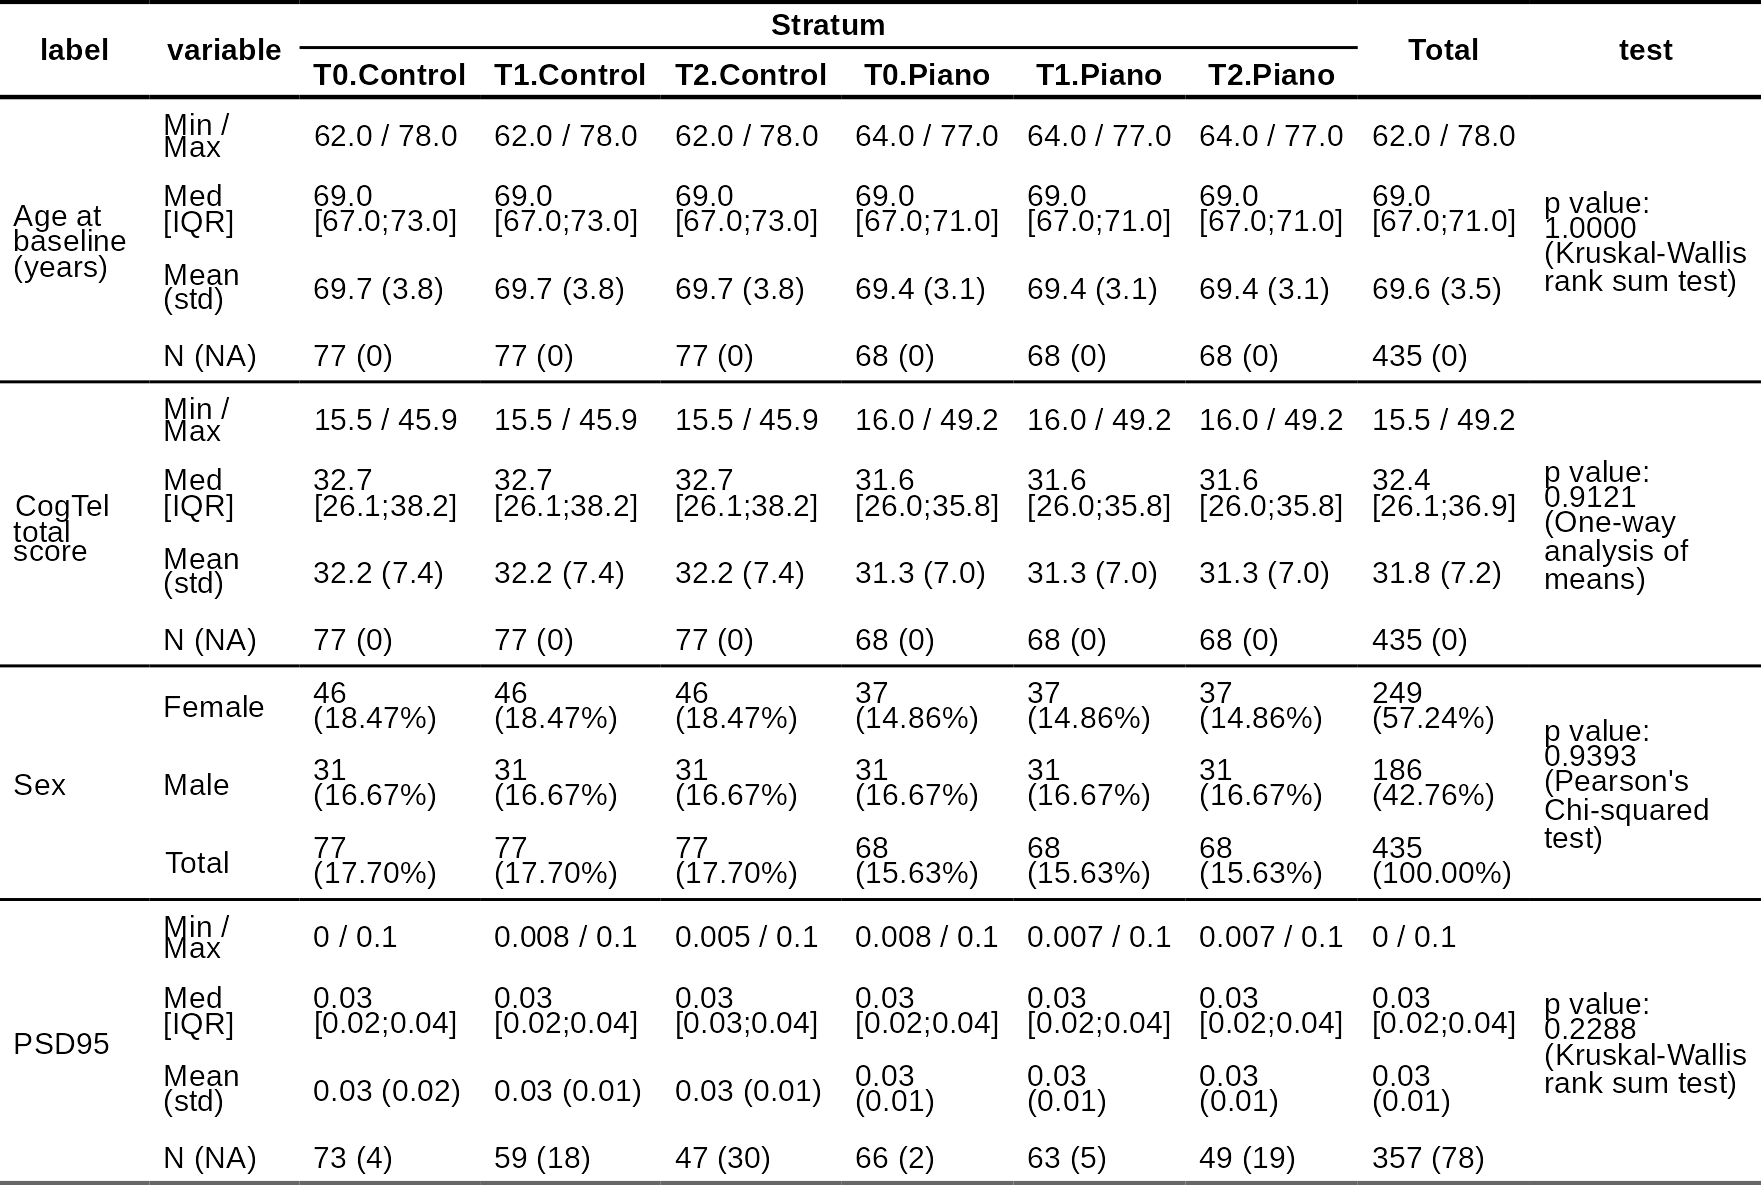

In [ ]:
#| label: psd95-crosstable-strata

psd95_time_long <- psd952 %>%
pivot_longer(T0:T2, names_to = "Time", values_to = "PSD95") %>%
mutate(
Time   = factor(Time, levels = c("T0", "T1", "T2")),
Gruppe = factor(Gruppe),
ID     = factor(ID),
Stratum= interaction(Time, Gruppe, drop = TRUE)
)

crosstable(
psd95_time_long,
c(Age_start, CogTel, Sex, PSD95),
by    = Stratum,
showNA= "ifany",
total = "both",
test  = TRUE
) %>%
as_flextable()